In [6]:
from __future__ import annotations
import torch
import torch.nn as nn

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import sys
import os

np.random.seed(42)
torch.manual_seed(0)

%matplotlib inline
%load_ext autoreload
%autoreload 2

# Question 1:
Implement and train an MLP as
specified in the assignment using PyTorch and multi-class cross entropy as the cost function. Experiment with
each of the four datasets to find the best number of nodes k from {2, 3, 5, 7, 9} in the hidden layer.

### Define network + dataloader

In [7]:
from dataclasses import dataclass
from typing import Any, Literal
import pathlib

from torch.utils.data import Dataset, DataLoader
import pandas as pd

# NETWORK DEFINITION
class ConorNet(nn.Module):
    """
    1xk neural network for HW1

    Here is a good clear reference for good nn code:
    https://docs.pytorch.org/tutorials/beginner/basics/optimization_tutorial.html
    """

    @dataclass(eq=True, order=True, unsafe_hash=True)
    class Hyperparams:
        """Hyperparameters for training + model"""
        k: int = 7
        """Number of nodes in the hidden layer. One of {2, 3, 5, 7, 9}"""

        activation: str | Literal["tanh", "relu", "sigmoid", "leaky"] = "tanh"
        learning_rate: float = 1E-3
        training_epochs: int = 5
        batch_size: int = 50

    def __init__(self, p: Hyperparams, use_softmax: bool = True):
        super().__init__()
        match p.activation:
            case "tanh":
                self._act = nn.Tanh()
            case "relu":
                self._act = nn.ReLU()
            case "sigmoid":
                self._act = nn.Sigmoid()
            case "leaky":
                self._act = nn.LeakyReLU()
            case _:
                raise NotImplementedError("Unrecognized activation function.")

        self.hparams = p

        # our network performs binary classification on an R2 input space, predicting 0 or 1.
        self._net = nn.Sequential(
            nn.Linear(2, self.hparams.k, bias=True),
            self._act,
            nn.Linear(self.hparams.k, 2 if use_softmax else 1, bias=True)
        )
        self._output = nn.Softmax(dim=1) if use_softmax else nn.Sigmoid()

    def forward(self, x):
        logits = self._net(x)
        return self._output(logits)
    
# DATALOADERS
class HW1Dataset(Dataset):
    """Dataset representation for the given CSV files

    they all have the same columns etc.
    """
    def __init__(self, csv_file: pathlib.Path) -> None:
        self.data = pd.read_csv(csv_file, header=0)

        # sanity check
        if list(self.data.columns) != ["label", "x1", "x2"]:
            raise ValueError(f"Incorrect column names {self.data.columns}")

        self.X = self.data[["x1", "x2"]].to_numpy(dtype=np.float32)
        self.y = self.data["label"].to_numpy(dtype=np.int64)
    
    def __len__(self) -> int:
        return len(self.data)

    def __getitem__(self, index) -> tuple[torch.Tensor, torch.Tensor]:
        return torch.tensor(self.X[index]), torch.tensor(self.y[index])

DSET_ROOT = pathlib.Path.cwd()
"""
Dataset root directory.

Sticking with the convention in the assignment zip, which is a flat directory with data + code.
"""

def smoke_test() -> None:
    # perform an initial evaluation, just to smoke test the code above.
    # doing this in function scope to not pollute the global namespace
    # i hate messy jupyter notebooks lol
    dset_path = DSET_ROOT / "spiral_train.csv"
    p = ConorNet.Hyperparams()

    train_dset = HW1Dataset(dset_path)
    train_dloader = DataLoader(train_dset, batch_size=p.batch_size, shuffle=True)

    print(f"Dataset: {dset_path}")
    print(f"len={len(train_dloader)}")
    xbatch, ybatch = next(iter(train_dloader))
    print(f"feature batch shape: {xbatch.size()}")
    print(f"label batch shape: {ybatch.size()}")
    print(f"idx 0--feat: {xbatch[0]}, label: {ybatch[0]}")

    print("\nEvaluating model...")
    model = ConorNet(p)
    # eval the model on the first batch we get
    logits: torch.Tensor = model(xbatch)
    print("logits: ")
    print(logits)

    # take argmax to get our yhat (since output node 0 = 0, output node 1 = 1)
    yhat = logits.argmax(dim=1)
    print("yhat:")
    print(yhat)

smoke_test()

Dataset: /home/conor/Documents/W2026/demeter_msai437/hw1/spiral_train.csv
len=4
feature batch shape: torch.Size([50, 2])
label batch shape: torch.Size([50])
idx 0--feat: tensor([-2.1221, -5.6075]), label: 1

Evaluating model...
logits: 
tensor([[0.3108, 0.6892],
        [0.5743, 0.4257],
        [0.3254, 0.6746],
        [0.6774, 0.3226],
        [0.6813, 0.3187],
        [0.6739, 0.3261],
        [0.4021, 0.5979],
        [0.6110, 0.3890],
        [0.6802, 0.3198],
        [0.6862, 0.3138],
        [0.3081, 0.6919],
        [0.6234, 0.3766],
        [0.4742, 0.5258],
        [0.3200, 0.6800],
        [0.4086, 0.5914],
        [0.6817, 0.3183],
        [0.6222, 0.3778],
        [0.6006, 0.3994],
        [0.6506, 0.3494],
        [0.4523, 0.5477],
        [0.6215, 0.3785],
        [0.6171, 0.3829],
        [0.6232, 0.3768],
        [0.6445, 0.3555],
        [0.3734, 0.6266],
        [0.6960, 0.3040],
        [0.2975, 0.7025],
        [0.6800, 0.3200],
        [0.3766, 0.6234],
        [

### Create Testing & Plotting Functions
Let's make my life easier by mostly automating:
- hyperparameter search (exhaustively over k, hand-wavily over other params)
- helpful debug plots for the hyperparam search
- plots & reports for the best set of hparams as required in the assignment

My general strategy will be to try to optimize the hyperparams other than k at k=5 for the two gaussians test, 
because I have a vague sense that'll be a pretty decent value with enough training epochs.

Then, once I have sane values for the other params, I'll try out all k values.

In [8]:
# first, some one-time setup stuff

# load all the datasets into a convenient map
def load_datasets() -> dict[str, dict[str, HW1Dataset]]:
    """Load all the datasets into a convenient map."""
    names = ["center_surround", "spiral", "two_gaussians", "xor"]
    types = ["test", "train", "valid"]

    dsets = dict()
    count = 0
    for name in names:
        dsets[name] = dict()
        for t_ in types:
            path = DSET_ROOT / f"{name}_{t_}.csv"
            dsets[name][t_] = HW1Dataset(path)
            count += 1
    
    print(f"loaded {count} datasets.")
    return dsets

DSETS = load_datasets()

loaded 12 datasets.


In [9]:
from itertools import product
from typing import Iterable

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

############
# train_loop() and test_loop() are from an example in the pytorch docs:
# (https://docs.pytorch.org/tutorials/beginner/basics/optimization_tutorial.html#full-implementation).

def train_loop(dataloader, model, loss_fn, optimizer, p: ConorNet.Hyperparams, debug_print=False, use_mce: bool = True) -> float:
    size = len(dataloader.dataset)
    # Set the model to training mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    model.train()
    model.to(DEVICE)
    loss = 0
    for batch, (X, y) in enumerate(dataloader):
        X = X.to(DEVICE)
        y = y.to(DEVICE)

        if not use_mce:
            y = y.float().unsqueeze(1)

        # Compute prediction and loss
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 100 == 0 and debug_print:
            loss, current = loss.item(), batch * p.batch_size + len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")
    
    return loss.item() # type: ignore


def test_loop(dataloader, model, loss_fn, p: ConorNet.Hyperparams, debug_print=False, use_mce: bool = True) -> tuple[float, float]:
    # Set the model to evaluation mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    model.eval()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0
    # Evaluating the model with torch.no_grad() ensures that no gradients are computed during test mode
    # also serves to reduce unnecessary gradient computations and memory usage for tensors with requires_grad=True
    with torch.no_grad():
        model.to(DEVICE)
        for X, y in dataloader:
            X = X.to(DEVICE)
            y = y.to(DEVICE)
            y_int = y

            if not use_mce:
                y = y.float().unsqueeze(1)

            pred = model(X)
            test_loss += loss_fn(pred, y).item()

            if use_mce:
                pred_labels = pred.argmax(1)
            else:
                pred_labels = (pred > 0.5).int().squeeze(1)

            correct += (pred_labels == y_int).type(torch.float).sum().item()

    test_loss /= num_batches
    correct /= size
    if debug_print:
        print(f"Test Performance - Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")
    
    return correct, test_loss

#################### end pytorch docs stuff ###########

def iterate_hyperparams_except_k():
    """Iterator for all the hyperparam combos i want to try"""
    k = [7]
    acts = ["tanh", "relu", "sigmoid", "leaky"]
    learns = [0.1, 0.01, 0.001]
    epochs = [5, 10, 20]
    batch = [1, 5, 50, 100]

    for k, act, lr, ep, bs in product(k, acts, learns, epochs, batch):
        yield ConorNet.Hyperparams(k=k, activation=act, learning_rate=lr, training_epochs=ep, batch_size=bs)

def train_hparams_on_dset(hparams: Iterable[ConorNet.Hyperparams], dset_name: str) -> tuple[dict[ConorNet.Hyperparams, ConorNet], dict[ConorNet.Hyperparams, float], dict[ConorNet.Hyperparams, list[float]], dict[ConorNet.Hyperparams, list[float]]]:
    """
    Train a model for each of the hyperparam combos

    Returns dict of hparams -> model, dict of hparams -> accuracy, dict of hparams -> loss curves
    """
    dset = DSETS[dset_name]
    out = dict()
    accuracy = dict()
    test_loss_curves = dict()
    train_loss_curves = dict()
    for hparam in hparams:
        print(f"\n~~~~~~~~~~~~~~~~~\nTRIAL: {hparam}")
        print(f"Dataset: {dset_name}; Device: {DEVICE}")

        # train the model
        train_data = DataLoader(dset["train"], batch_size=hparam.batch_size, shuffle=True)
        test_data = DataLoader(dset["test"], batch_size=hparam.batch_size, shuffle=True)

        model = ConorNet(hparam)
        # could maybe have the optimizer as a hyperparam later?
        optimizer = torch.optim.Adam(model.parameters(), lr=hparam.learning_rate)
        loss_fn = nn.CrossEntropyLoss()
        model.to(DEVICE)
        
        acc = 0
        test_losses = []
        train_losses = []
        for epoch in range(hparam.training_epochs):
            print(f"EPOCH {epoch}")
            train_loss = train_loop(train_data, model, loss_fn, optimizer, hparam)
            acc, test_loss = test_loop(test_data, model, loss_fn, hparam, debug_print=True)
            test_losses.append(test_loss)
            train_losses.append(train_loss)
        
        # model is trained
        out[hparam] = model
        accuracy[hparam] = acc
        test_loss_curves[hparam] = test_losses
        train_loss_curves[hparam] = train_losses
    
    return out, accuracy, test_loss_curves, train_loss_curves

# first, try out the default; a brief basic test.
np.random.seed(0)
torch.manual_seed(0)
train_hparams_on_dset([ConorNet.Hyperparams()], "two_gaussians")



~~~~~~~~~~~~~~~~~
TRIAL: ConorNet.Hyperparams(k=7, activation='tanh', learning_rate=0.001, training_epochs=5, batch_size=50)
Dataset: two_gaussians; Device: cuda
EPOCH 0
Test Performance - Accuracy: 50.0%, Avg loss: 0.690741 

EPOCH 1
Test Performance - Accuracy: 50.0%, Avg loss: 0.684829 

EPOCH 2
Test Performance - Accuracy: 50.0%, Avg loss: 0.679033 

EPOCH 3
Test Performance - Accuracy: 50.0%, Avg loss: 0.673322 

EPOCH 4
Test Performance - Accuracy: 50.5%, Avg loss: 0.667715 



({ConorNet.Hyperparams(k=7, activation='tanh', learning_rate=0.001, training_epochs=5, batch_size=50): ConorNet(
    (_act): Tanh()
    (_net): Sequential(
      (0): Linear(in_features=2, out_features=7, bias=True)
      (1): Tanh()
      (2): Linear(in_features=7, out_features=2, bias=True)
    )
    (_output): Softmax(dim=1)
  )},
 {ConorNet.Hyperparams(k=7, activation='tanh', learning_rate=0.001, training_epochs=5, batch_size=50): 0.505},
 {ConorNet.Hyperparams(k=7, activation='tanh', learning_rate=0.001, training_epochs=5, batch_size=50): [0.690740630030632,
   0.6848291009664536,
   0.6790326982736588,
   0.6733221709728241,
   0.6677152663469315]},
 {ConorNet.Hyperparams(k=7, activation='tanh', learning_rate=0.001, training_epochs=5, batch_size=50): [0.6839249134063721,
   0.7111018300056458,
   0.700394868850708,
   0.6480340361595154,
   0.6392359733581543]})

In [10]:
# evaluate every model (in its own cell so I can iterate more quickly on plotting code)
np.random.seed(0)
torch.manual_seed(0)
GRID_SEARCH_MODELS, GRID_SEARCH_ACCURACY, _, _ = train_hparams_on_dset(iterate_hyperparams_except_k(), "two_gaussians")


~~~~~~~~~~~~~~~~~
TRIAL: ConorNet.Hyperparams(k=7, activation='tanh', learning_rate=0.1, training_epochs=5, batch_size=1)
Dataset: two_gaussians; Device: cuda
EPOCH 0
Test Performance - Accuracy: 85.0%, Avg loss: 0.453520 

EPOCH 1
Test Performance - Accuracy: 50.0%, Avg loss: 0.813262 

EPOCH 2
Test Performance - Accuracy: 50.0%, Avg loss: 0.813262 

EPOCH 3
Test Performance - Accuracy: 50.0%, Avg loss: 0.813262 

EPOCH 4
Test Performance - Accuracy: 50.0%, Avg loss: 0.813262 


~~~~~~~~~~~~~~~~~
TRIAL: ConorNet.Hyperparams(k=7, activation='tanh', learning_rate=0.1, training_epochs=5, batch_size=5)
Dataset: two_gaussians; Device: cuda
EPOCH 0
Test Performance - Accuracy: 92.5%, Avg loss: 0.387549 

EPOCH 1
Test Performance - Accuracy: 91.5%, Avg loss: 0.401173 

EPOCH 2
Test Performance - Accuracy: 86.0%, Avg loss: 0.443962 

EPOCH 3
Test Performance - Accuracy: 91.0%, Avg loss: 0.399480 

EPOCH 4
Test Performance - Accuracy: 91.0%, Avg loss: 0.399675 


~~~~~~~~~~~~~~~~~
TRIAL: Cono

In [11]:
# grab the most accurate model
best_hparams = max(GRID_SEARCH_ACCURACY, key=lambda h: GRID_SEARCH_ACCURACY[h])
best_acc = GRID_SEARCH_ACCURACY[best_hparams]

print(f"Best accuracy was {best_acc * 100:<.1f}%, with params {best_hparams}")
pd.Series(GRID_SEARCH_ACCURACY.values()).describe()

Best accuracy was 93.5%, with params ConorNet.Hyperparams(k=7, activation='tanh', learning_rate=0.01, training_epochs=20, batch_size=100)


count    144.000000
mean       0.831285
std        0.168063
min        0.090000
25%        0.861250
50%        0.910000
75%        0.915000
max        0.935000
dtype: float64

## Initial Grid Search Evaluation Results
So -- I get 93% accuracy with these hyperparameters:
- k = 7
- activation = tanh
- learning rate = 0.1
- training epochs = 20
- batch_size = 50
- optimizer = Adam
- loss = MCE (with softmax output layer)

This isn't particularly rigorous, since this result may be happenstance associated
with particularly good starting weights, since I set a the same RNG seed every time; and also, this 
result (even if valid) may not be representative of the other training datasets. But I'll be trying it with more
examples shortly, and all I need are "good enough" values, really.

Time to test out different values of k:

In [12]:

def iterate_hyperparams_k():
    """Iterator for varying k in the hyperparams, with all others set to good values"""
    k = [2, 3, 5, 7, 9]
    acts = ["tanh"]
    learns = [0.1]
    epochs = [20]
    batch = [50]

    for k, act, lr, ep, bs in product(k, acts, learns, epochs, batch):
        yield ConorNet.Hyperparams(k=k, activation=act, learning_rate=lr, training_epochs=ep, batch_size=bs)

def eval_ks() -> tuple[dict[str, ConorNet.Hyperparams], dict[str, float], dict[str, dict[ConorNet.Hyperparams, list[float]]]]:
    """evaluate the model for several k values across all datasets, getting the best k for each"""
    out_params = dict()
    out_accs = dict()
    out_test_loss = dict()
    out_train_loss = dict()
    for dset_name in ["two_gaussians", "center_surround", "spiral", "xor"]:
        GRID_SEARCH_MODELS, GRID_SEARCH_ACCURACY, test_loss, train_loss = train_hparams_on_dset(iterate_hyperparams_k(), dset_name)

        # grab the most accurate model
        best_hparams = max(GRID_SEARCH_ACCURACY, key=lambda h: GRID_SEARCH_ACCURACY[h])
        best_acc = GRID_SEARCH_ACCURACY[best_hparams]

        print(f"Best accuracy was {best_acc * 100:<.1f}%, with params {best_hparams}")
        print(pd.Series(GRID_SEARCH_ACCURACY.values()).describe())

        out_params[dset_name] = best_hparams
        out_accs[dset_name] = best_acc
        out_test_loss[dset_name] = test_loss
        out_train_loss[dset_name] = train_loss
    
    return out_params, out_accs, out_test_loss

best_params_per_dataset, _, _ = eval_ks()


~~~~~~~~~~~~~~~~~
TRIAL: ConorNet.Hyperparams(k=2, activation='tanh', learning_rate=0.1, training_epochs=20, batch_size=50)
Dataset: two_gaussians; Device: cuda
EPOCH 0
Test Performance - Accuracy: 79.0%, Avg loss: 0.542617 

EPOCH 1
Test Performance - Accuracy: 86.0%, Avg loss: 0.476350 

EPOCH 2
Test Performance - Accuracy: 91.0%, Avg loss: 0.427712 

EPOCH 3
Test Performance - Accuracy: 91.5%, Avg loss: 0.408320 

EPOCH 4
Test Performance - Accuracy: 92.0%, Avg loss: 0.400291 

EPOCH 5
Test Performance - Accuracy: 91.5%, Avg loss: 0.393482 

EPOCH 6
Test Performance - Accuracy: 91.5%, Avg loss: 0.392428 

EPOCH 7
Test Performance - Accuracy: 91.5%, Avg loss: 0.392722 

EPOCH 8
Test Performance - Accuracy: 91.5%, Avg loss: 0.395478 

EPOCH 9
Test Performance - Accuracy: 90.5%, Avg loss: 0.397132 

EPOCH 10
Test Performance - Accuracy: 90.5%, Avg loss: 0.398040 

EPOCH 11
Test Performance - Accuracy: 91.5%, Avg loss: 0.398371 

EPOCH 12
Test Performance - Accuracy: 90.5%, Avg loss: 0

## Best K Values Evaluation Results (Q1)
As can be seen in the cell results above, those hyperparameters did indeed perform
well enough across all datasets (ranging on my run from 77% - 94%); however, different values of k were more effective for different datasets.

Let's visualize these tuned models in more detail.

Evaluating two_gaussians on ConorNet.Hyperparams(k=2, activation='tanh', learning_rate=0.1, training_epochs=20, batch_size=50)...
Evaluating center_surround on ConorNet.Hyperparams(k=5, activation='tanh', learning_rate=0.1, training_epochs=20, batch_size=50)...
Evaluating spiral on ConorNet.Hyperparams(k=5, activation='tanh', learning_rate=0.1, training_epochs=20, batch_size=50)...
Evaluating xor on ConorNet.Hyperparams(k=9, activation='tanh', learning_rate=0.1, training_epochs=20, batch_size=50)...


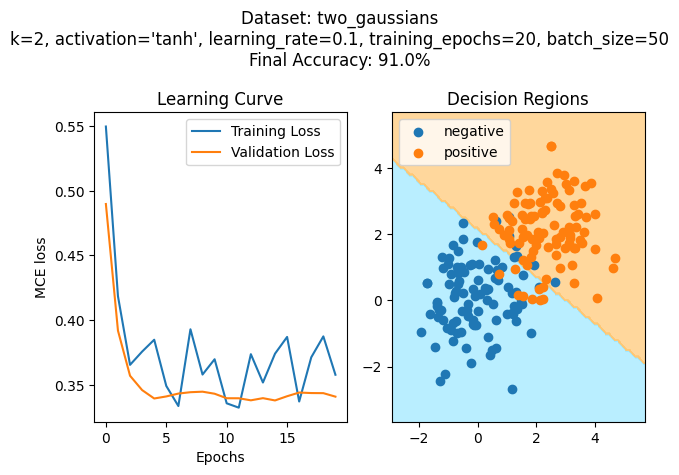

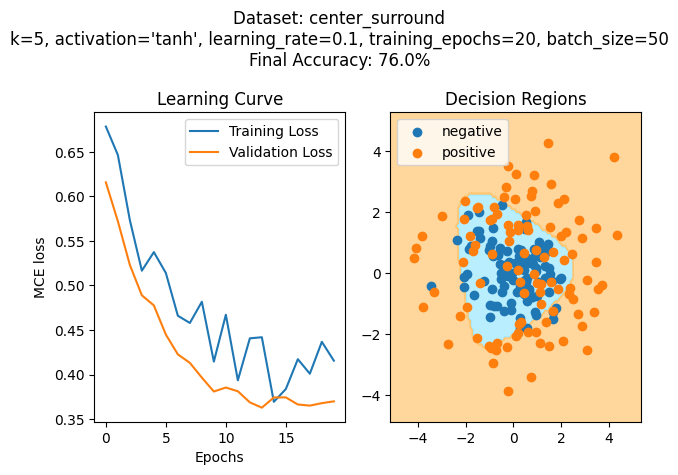

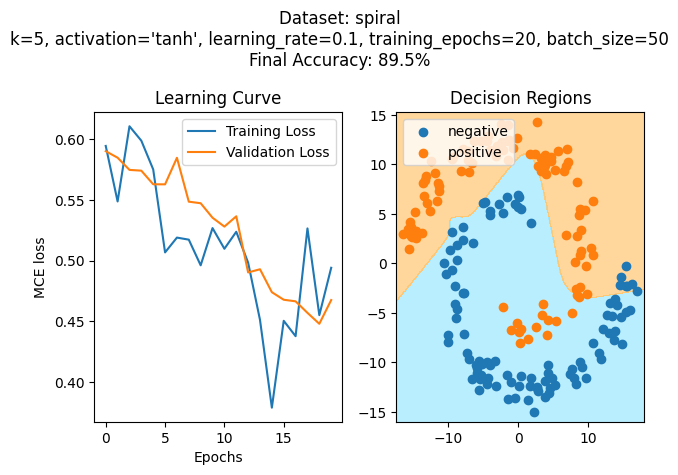

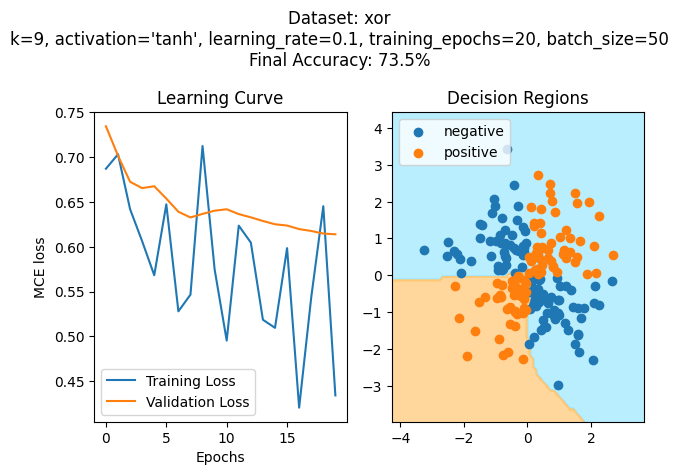

In [13]:
from dataclasses import field
import matplotlib.colors

# alright. time i make this a bit easier on myself. it's feeling like a "run" deserves its own
# class so i'm not dragging all these variables around

@dataclass
class RunResults:
    # keeping these for ease later
    model: ConorNet
    data: dict[str, HW1Dataset]

    # overall test accuracy
    test_accuracy: float = 0

    # both as a function of training epoch #
    training_loss: list[float] = field(default_factory=list)
    validation_loss: list[float] = field(default_factory=list)

class TrainAndTestRun:
    def __init__(self, hparams: ConorNet.Hyperparams, dset_name: str, use_mce: bool = True) -> None:
        self.h = hparams
        self.use_mce = use_mce
        self.model = ConorNet(hparams, use_mce)
        self.dset = DSETS[dset_name]
        self.dset_name = dset_name
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=self.h.learning_rate)
        if use_mce:
            self.loss_fn = nn.CrossEntropyLoss()
        else:
            self.loss_fn = nn.MSELoss()

        # bookkeeping from eval
        self.results: RunResults | None = None

    def eval(self) -> RunResults:
        print(f"Evaluating {self.dset_name} on {self.h}...")
        train_loader = DataLoader(self.dset["train"], batch_size=self.h.batch_size, shuffle=True)
        test_loader = DataLoader(self.dset["test"], batch_size=self.h.batch_size, shuffle=True)
        validation_loader = DataLoader(self.dset["valid"], batch_size=self.h.batch_size, shuffle=True)

        res = RunResults(self.model, self.dset)

        test_acc = 0
        for epoch in range(self.h.training_epochs):
            train_loss = train_loop(train_loader, self.model, self.loss_fn, 
                                    self.optimizer, self.h, debug_print=False, use_mce=self.use_mce)
            test_acc, test_loss = test_loop(test_loader, self.model, self.loss_fn, self.h, debug_print=False, use_mce=self.use_mce)
            valid_acc, valid_loss = test_loop(validation_loader, self.model, self.loss_fn, self.h, debug_print=False, use_mce=self.use_mce)

            res.training_loss.append(train_loss)
            res.validation_loss.append(valid_loss)
        
        res.test_accuracy = test_acc
        self.results = res
        return res

########### Plotting helpers from example code
def compute_bounds(features):
    min1, max1 = features[:, 0].min()-1, features[:, 0].max()+1
    min2, max2 = features[:, 1].min()-1, features[:, 1].max()+1
    return (min1, max1, min2, max2)


def plot_decision_regions(
        features, targets, model,
        axis=None, transform=None,
        bounds=None,
        title='Decision Surface'):
    """
    Slightly different plotting approach than above. Used in backprop demo.

    This function produces a single plot containing a scatter plot of the
    features, targets, and decision region of the model.

    Args:
        features (np.ndarray): 2D array containing real-valued inputs.
        targets (np.ndarray): 1D array containing binary targets.
        model: a learner with .predict() method
        axis: the axis on which to plot. If None, create a new plot
        title: title of the plot
    Returns:
        None (plots to the active figure)
    """

    # define bounds of the domain
    if bounds is None:
        min1, max1, min2, max2 = compute_bounds(features)
    else:
        min1, max1, min2, max2 = bounds

    # define grid for visualizing decision regions
    x1grid = np.arange(min1, max1, 0.1)
    x2grid = np.arange(min2, max2, 0.1)

    xx, yy = np.meshgrid(x1grid, x2grid)

    # flatten grid to a vector
    r1, r2 = xx.flatten(), yy.flatten()
    r1, r2 = r1.reshape((len(r1), 1)), r2.reshape((len(r2), 1))

    # horizontally stack vectors to create x1,x2 input for the model
    grid = np.hstack((r1,r2))

    # if we're transforming the features, do that now
    #     this allows xx and yy to still be in 2D for the visualization
    #     but grid has been transformed so it matches up with the fit model
    if transform is not None:
        grid = transform(grid)

    # generate predictions over grid
    yhat = model(grid)

    # reshape the predictions back into a grid
    zz = yhat.reshape(xx.shape)

    if axis is None:
        fig, axis = plt.subplots()

    # plot the grid of x, y and z values as a surface
    binary_cmap = matplotlib.colors.ListedColormap(['#9ce8ff', '#ffc773'])
    axis.contourf(xx, yy, zz, cmap=binary_cmap, alpha=0.7)

    # plot "negative" class:
    row_idx_neg = np.where(targets < 0.5)[0]
    axis.scatter(
        features[row_idx_neg, 0], features[row_idx_neg, 1],
        label='negative')

    # plot "positive" class:
    row_idx_pos = np.where(targets > 0.5)[0]
    axis.scatter(
        features[row_idx_pos, 0], features[row_idx_pos, 1],
        label='positive')

    axis.set_title(title)
    axis.set_xlim(min1, max1)
    axis.set_ylim(min2, max2)

    axis.legend(loc="upper left")

################# end plotting helpers
 

def eval_and_plot(dset_params: Iterable[tuple[str, ConorNet.Hyperparams]], use_mce: bool = True) -> None:
    # evaluate the model on test & train
    for dset_name, hparams in dset_params:
        # rerun each so we collect the right data
        run = TrainAndTestRun(hparams, dset_name, use_mce)
        res = run.eval()

        # plot learning curves
        fig = plt.figure()
        ax0, ax1 = fig.subplots(1,2)

        ax0.plot(range(hparams.training_epochs), res.training_loss, label="Training Loss")
        ax0.plot(range(hparams.training_epochs), res.validation_loss, label="Validation Loss")
        ax0.set_xlabel("Epochs")
        ax0.set_ylabel("MCE loss")
        ax0.set_title("Learning Curve") 
        ax0.legend()

        paramstr = str(hparams).replace("ConorNet.Hyperparams(", "").replace(")", "")
        fig.suptitle(f"Dataset: {dset_name}\n{paramstr}\nFinal Accuracy: {100*res.test_accuracy:.1f}%")

        if use_mce:
            output_map = lambda x: res.model(torch.Tensor(x).to(DEVICE)).argmax(axis=1).cpu()
        else:
            output_map = lambda x: (res.model(torch.Tensor(x).to(DEVICE)) > 0.5).int().cpu().numpy().ravel()

        plot_decision_regions(res.data["test"].X, res.data["test"].y, 
                              output_map,
                              axis=ax1,
                              title="Decision Regions")
        
        plt.tight_layout()

torch.manual_seed(0)
eval_and_plot(best_params_per_dataset.items())


## Q1 - Results
### Best k values per dataset + accuracy
- two_gaussians: k=2 (91.0% accurate)
- center_surround: k=5 (76.0% accurate)
- spiral: k=5 (89.5% accurate)
- xor: k=9 (73.5% accurate)

### Discuss your design choices and comment on how they impact performance. 
TODO

# Q2 - MSE loss + sigmoids output layer
Repeat Step 1 using mean-squared error as the cost function. You may want to use a sigmoid function as the output layer of your network
and apply a threshold of 0.5 to assign labels at test time.

Let's start by testing a simple example.

Evaluating two_gaussians on ConorNet.Hyperparams(k=7, activation='tanh', learning_rate=0.1, training_epochs=20, batch_size=50)...


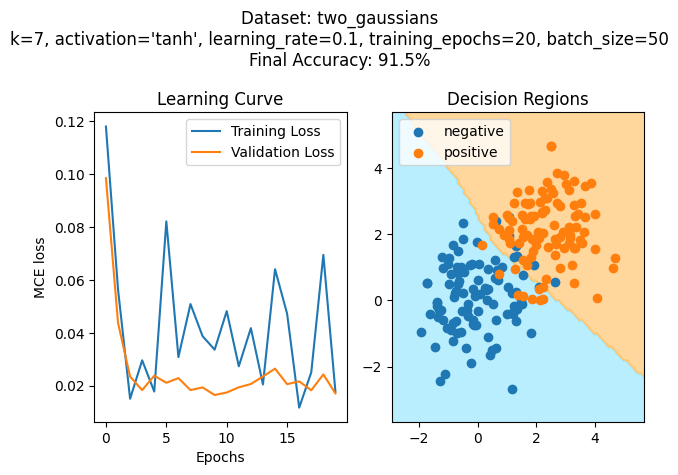

In [14]:
# try running on the default hyperparams
eval_and_plot([("two_gaussians", ConorNet.Hyperparams(learning_rate=0.1, training_epochs=20))], use_mce=False)

Alright, now let's find the best k's (with similar hyperparameters to before) and plot them.

Evaluating center_surround on ConorNet.Hyperparams(k=2, activation='tanh', learning_rate=0.1, training_epochs=40, batch_size=50)...
Evaluating center_surround on ConorNet.Hyperparams(k=3, activation='tanh', learning_rate=0.1, training_epochs=40, batch_size=50)...
Evaluating center_surround on ConorNet.Hyperparams(k=5, activation='tanh', learning_rate=0.1, training_epochs=40, batch_size=50)...
Evaluating center_surround on ConorNet.Hyperparams(k=7, activation='tanh', learning_rate=0.1, training_epochs=40, batch_size=50)...
Evaluating center_surround on ConorNet.Hyperparams(k=9, activation='tanh', learning_rate=0.1, training_epochs=40, batch_size=50)...
Evaluating spiral on ConorNet.Hyperparams(k=2, activation='tanh', learning_rate=0.1, training_epochs=40, batch_size=50)...
Evaluating spiral on ConorNet.Hyperparams(k=3, activation='tanh', learning_rate=0.1, training_epochs=40, batch_size=50)...
Evaluating spiral on ConorNet.Hyperparams(k=5, activation='tanh', learning_rate=0.1, training_

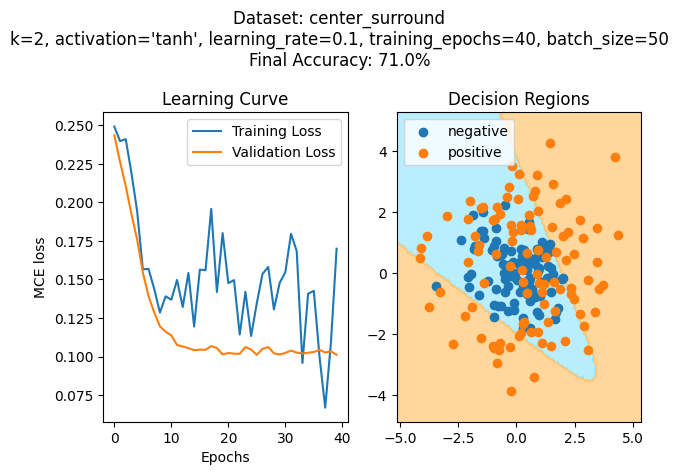

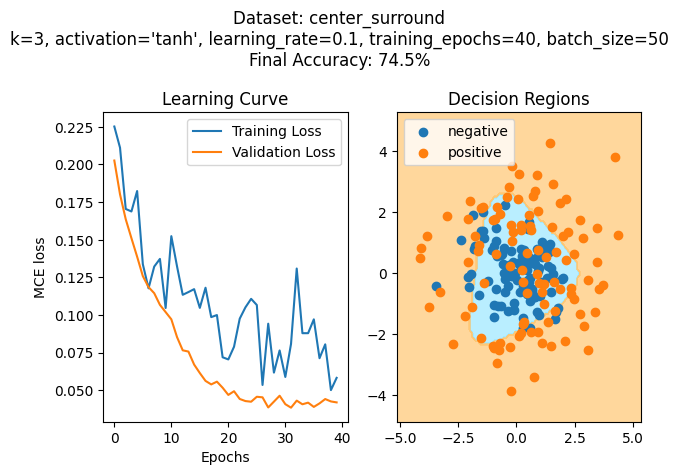

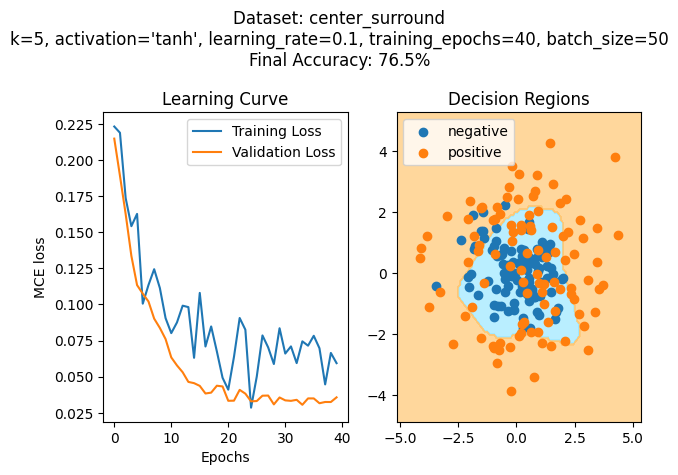

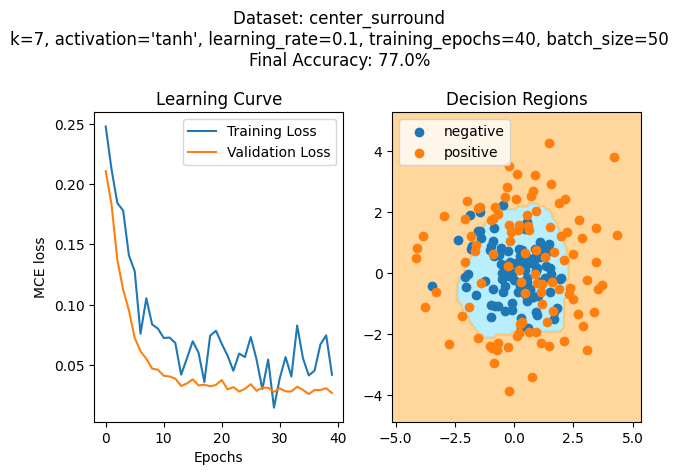

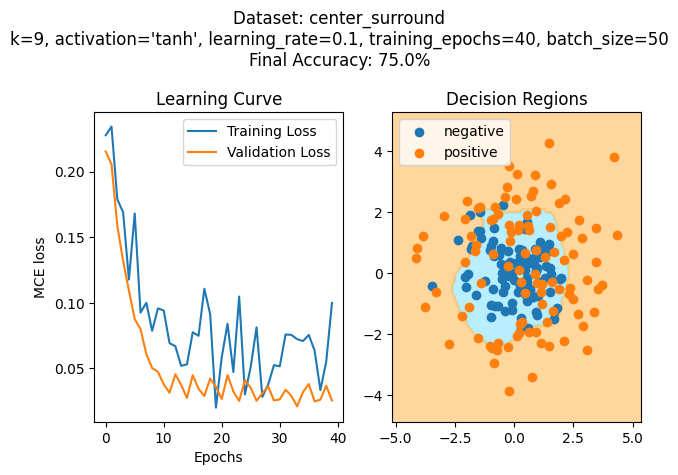

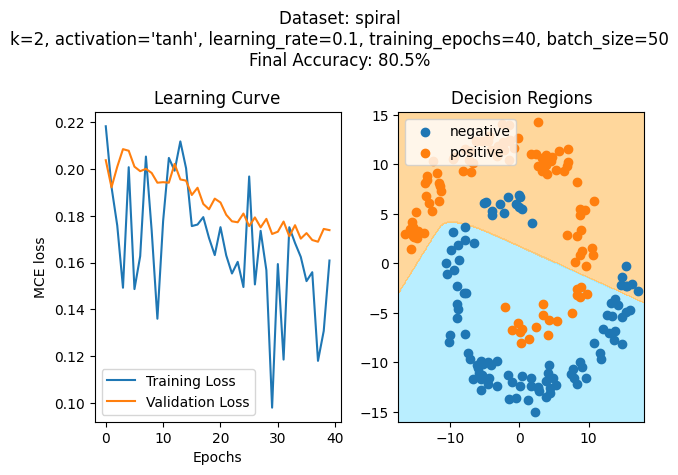

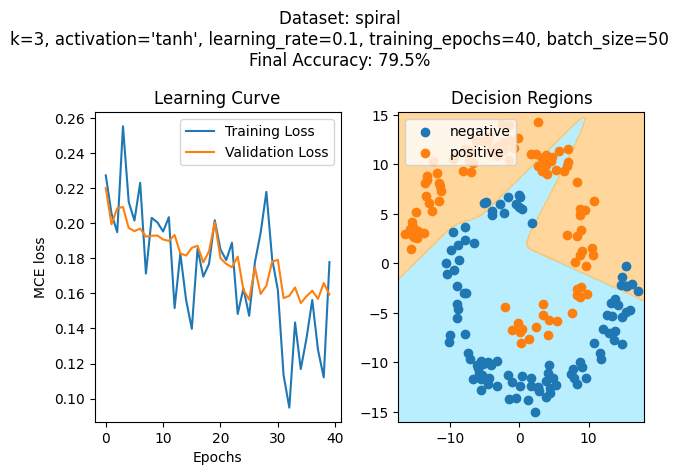

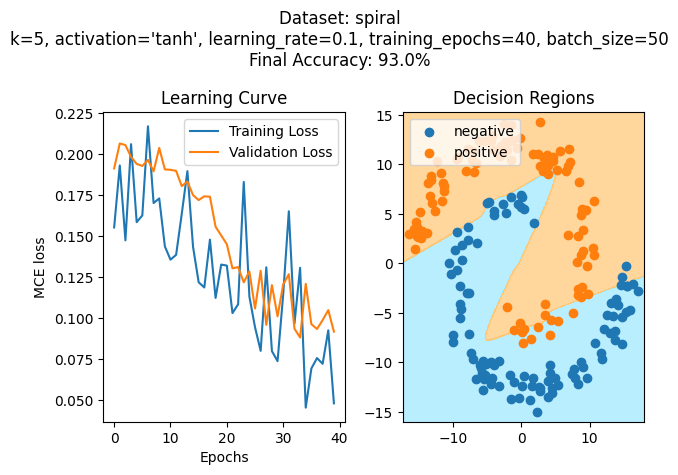

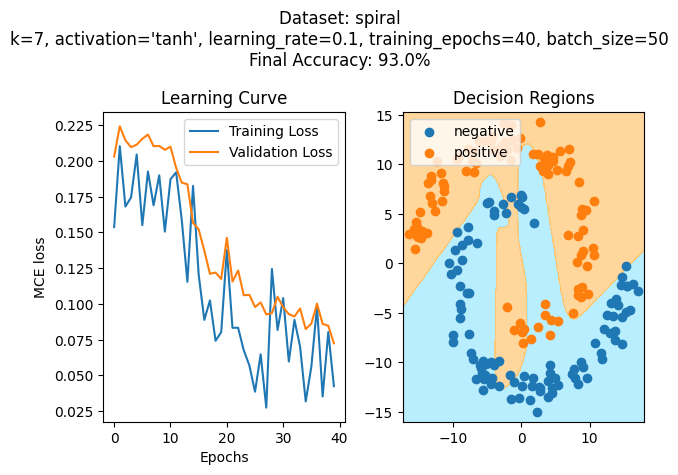

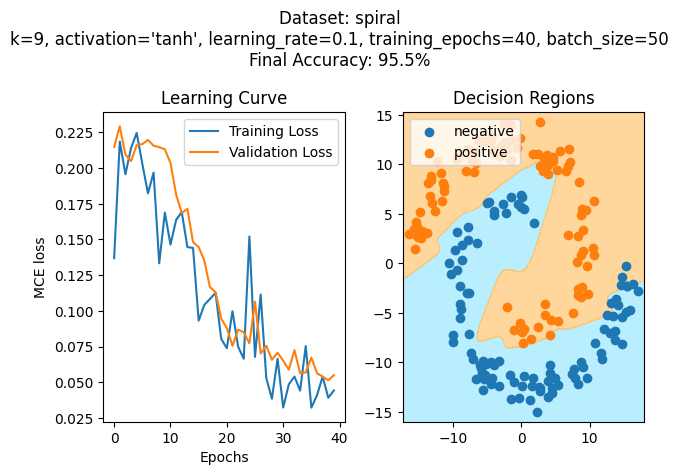

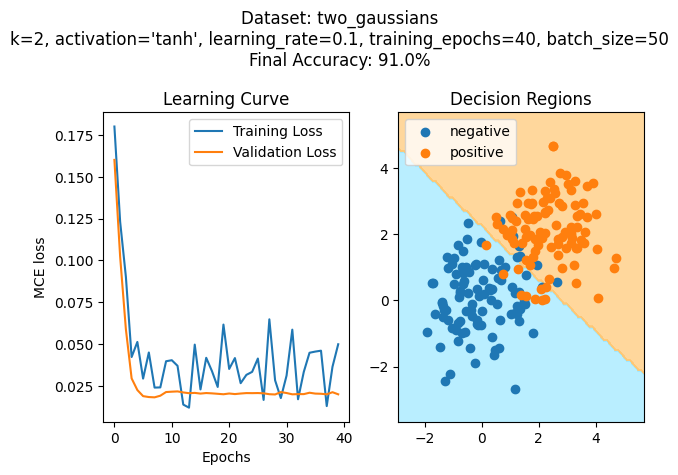

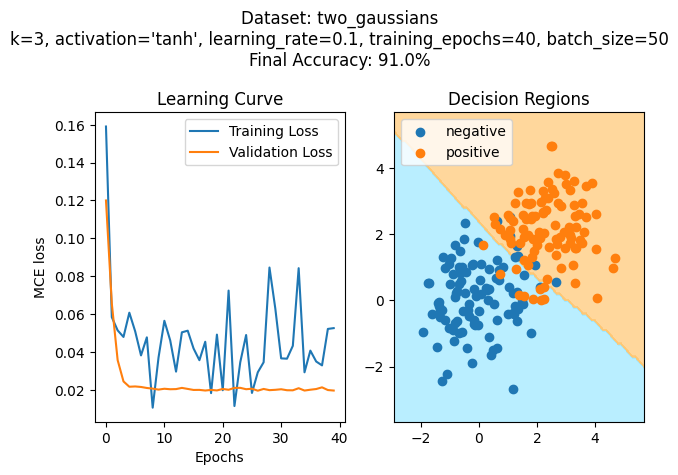

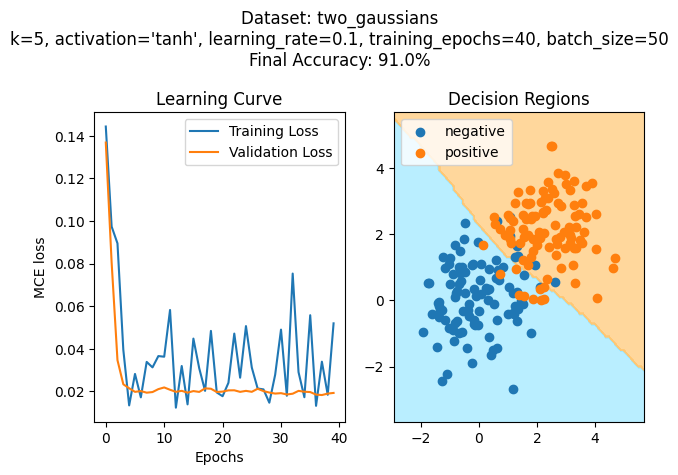

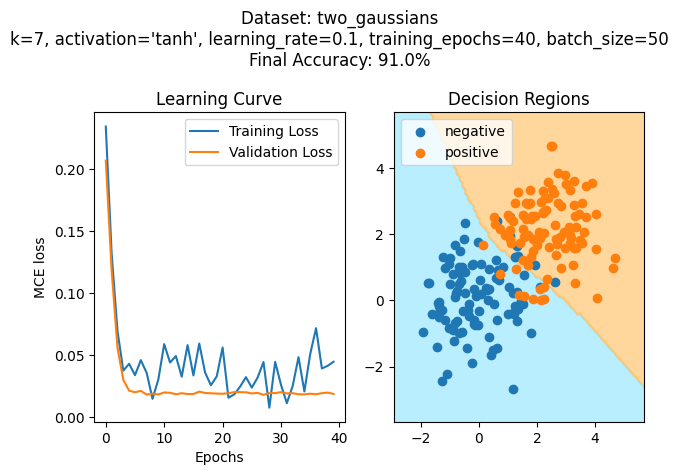

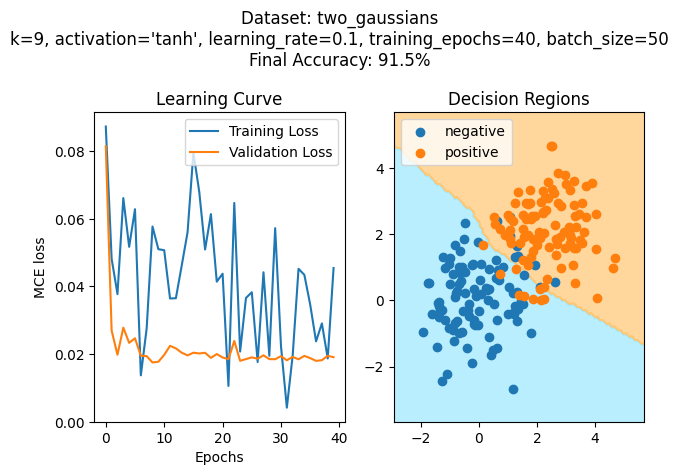

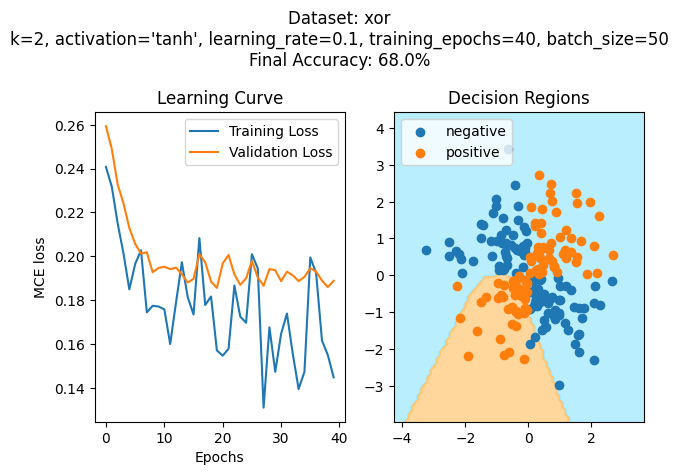

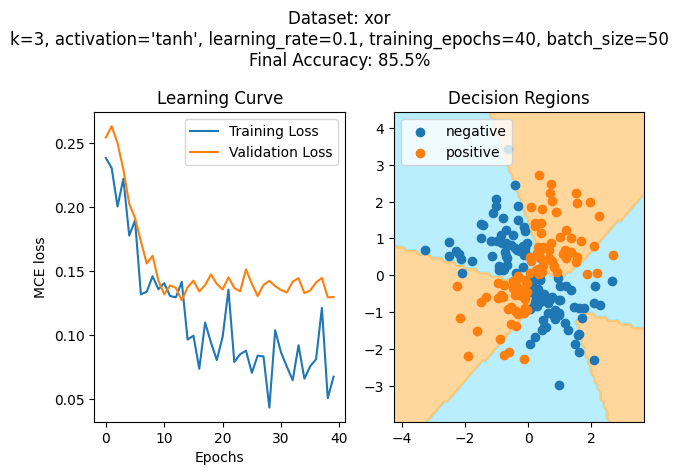

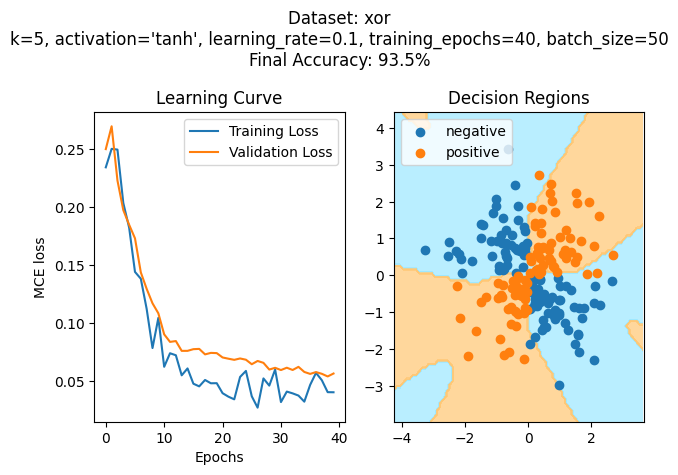

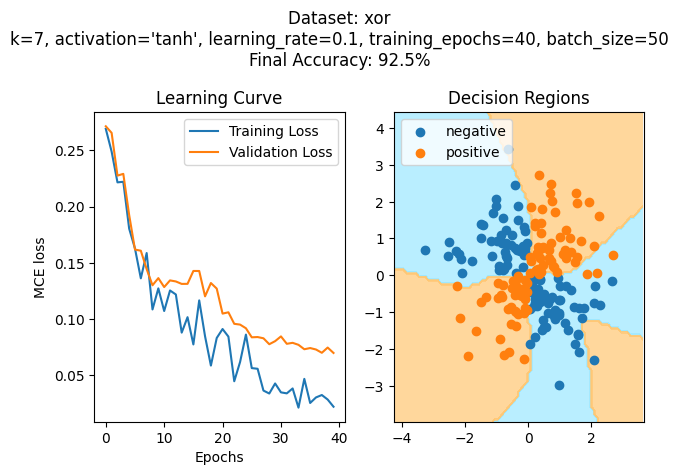

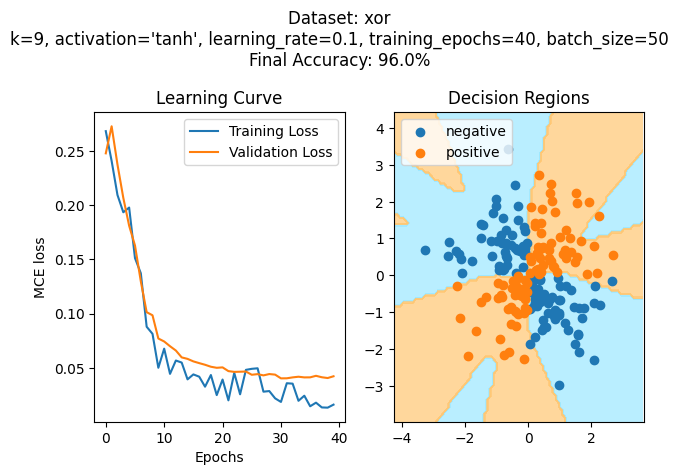

In [15]:
# gonna use the new class here rather than the old code. I think will be easier
def iterate_hyperparams_k():
    """Iterator for varying k in the hyperparams, with all others set to good values"""
    k = [2, 3, 5, 7, 9]
    acts = ["tanh"]
    learns = [0.1]
    # gonna try increasing this here just for kicks
    epochs = [40]
    batch = [50]

    for k, act, lr, ep, bs in product(k, acts, learns, epochs, batch):
        yield ConorNet.Hyperparams(k=k, activation=act, learning_rate=lr, training_epochs=ep, batch_size=bs)

def find_best_k_mse():
    combos = []
    for dset_name in DSETS.keys():
        for hp in iterate_hyperparams_k():
            combos.append((dset_name, hp))

    # why not just plot everything? easy to now. will be interesting to see all of the plots.
    torch.manual_seed(0)
    eval_and_plot(combos, use_mce=False)

find_best_k_mse()

# Q2 - Results

The above plots are the results of _all_ k values for my hyperparameters on each dataset.
I include all of them because the visual intuition gained by seeing how the k values change the learning curve and decision boundary 
was very helpful to me in understanding what's happening.

### Best K-values
- center_surround: k=7 (77.0% accurate)
    - it would be difficult to score higher than this due to the degree to which the regions overlap. Any number k>2 does pretty well.
- spiral: k=9 (95.5% accurate)
    - k=9 really matters here. Lower values of k visibly struggle to learn the shape. Because the 0 & 1 regions are entirely non-overlapping, we can learn to be quite accurate here.
- two_gaussians: k=9 (91.5% accurate)
    - any k value does pretty well here. The boundary is nearly a straight line; I think if anything, k=9 actually overfits, though it does well on the validation set.
- xor: k=9 (96% accurate)
    - Again, k<7 struggles to learn this complex shape. However, I think k=9 overfits a bit, though it does well on validation. 

### Qualitative Takeaways
#### Effect of Epoch Count
Overall, these results are visually & quantitatively stronger than my results in Q1. I attribute this primarily to my increasing the epoch count from 20 to 30. I did this based on a hunch, since the Q1 hyperparam grid search showed best performance at 20 (the max I gave) for every dataset. I'd like to run my Q1 grid analysis again with this higher epoch count included, but will do this separately if I have time rather than going back and modifying my earlier work in order to preserve my original Q1 analysis. 

#### Learning Curves by Dataset and k-value
In general above, we can see that the learning curve shape is qualitatively affected by dataset and k-value in 2 intuitive ways:
1. The more complicated (i.e. nonlinear, non-contiguous) the decision boundary, the longer it takes to learn (i.e. the longer it takes the learning curve to start flattening out). In particular, the xor and spiral shapes take longer to learn than the gaussian and center_surround datasets. An interesting anecdotal note is that when we compare against the decision boundaries seen in at lower epoch count in Q1, we can see that at epoch 20, the network hasn't figured out how to create non-contiguous decision boundaries yet. 
2. The k-value sets the floor for the learning curve. More complicated shapes (spiral, xor) are simply impossible to represent well with 2 or 3 hidden nodes. 

# Q3 - Neural Net From Scratch

To make this easier on myself, I will implement most of this code in actual python files, then import & test them here.

Let's start by getting the forward pass and gradient calculation working using a calculation graph.

In [16]:
import scratch_nnet as snn
import scratch_loss as sloss
import numpy as np

def test_basic():
    model = snn.ScratchMSENet(snn.ScratchMSENet.Hyperparams(k=7, learning_rate=0.001, training_epochs=30, batch_size=50))

    # forward pass
    X = np.array([[0.0, 0.0], [1.0, 1.0]])
    y = np.array([[0], [1]])
    yhat = model.forward(X)

    print(f"yhat: {yhat}")

    # calculate gradients
    # Backward pass
    loss_fn = sloss.MSELoss()
    dloss = loss_fn.backward(y, yhat)
    dX = model.backward(dloss)

    # this isn't really that useful but it's at least an indication that the gradient calc
    # occurred and produced something of the right shape.
    print(f"dX: {dX}")

test_basic()

yhat: [[0.49943665]
 [0.49933852]]
dX: [[-2.62227420e-05 -2.28033472e-05]
 [ 2.62684150e-05  2.28286707e-05]]


In [17]:
# now let's try the optimizer

import scratch_optimizer as sopt
import scratch_nnet as snn
import scratch_loss as sloss

def test_sgd_optimizer():
    """Test SGD optimizer with scratch network."""
    model = snn.ScratchMSENet(snn.ScratchMSENet.Hyperparams(k=7, learning_rate=0.1, training_epochs=30, batch_size=50))
    
    # Create optimizer
    optimizer = sopt.SGD(model.parameters(), learning_rate=0.01)
    
    # forward pass
    X = np.array([[0.0, 0.0], [1.0, 1.0]])
    y = np.array([[0], [1]])
    yhat = model.forward(X)
    
    print(f"yhat before update:\n{yhat}")
    
    # backward pass
    loss_fn = sloss.MSELoss()
    dloss = loss_fn.backward(y, yhat)
    model.backward(dloss)
    
    # check on gradients. shapes should be (3, 8), (8, 2) for the 2 linear layers with k=7 + bias for each.
    grads = model.grads()
    print(f"\nNumber of gradient arrays: {len(grads)}")
    print(f"Gradient shapes: {[g.shape for g in grads]}")
    
    # one step of gradient descent
    optimizer.step(grads)
    
    # forward pass after update
    yhat_updated = model.forward(X)
    print(f"\nyhat after update:\n{yhat_updated}")
    print(f"Difference: {np.abs(yhat - yhat_updated).max():.6f}")

test_sgd_optimizer()

yhat before update:
[[0.49795977]
 [0.49795847]]

Number of gradient arrays: 2
Gradient shapes: [(3, 8), (8, 2)]

yhat after update:
[[0.49796245]
 [0.49796175]]
Difference: 0.000003


Alright. Let's try evaluating the from-scratch NN visually as above on a dataset to make sure it works.

Best Scratch NN accuracy for dataset two_gaussians: Accuracy=91.50%, HParams=ScratchMSENet.Hyperparams(k=7, learning_rate=0.5, training_epochs=50, batch_size=50)


({'two_gaussians': 0.915},
 {'two_gaussians': ScratchMSENet.Hyperparams(k=7, learning_rate=0.5, training_epochs=50, batch_size=50)})

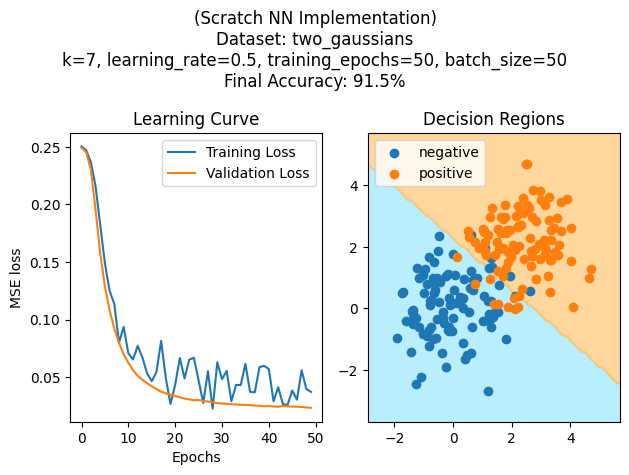

In [18]:
import pandas as pd
import numpy as np

import scratch_nnet as snn
import scratch_optimizer as sopt
import runner


def load_dataset_scratch() -> dict[str, dict[str, tuple[np.ndarray, np.ndarray]]]:
    names = ["center_surround", "spiral", "two_gaussians", "xor"]
    types = ["test", "train", "valid"]

    dsets: dict[str, dict[str, tuple[np.ndarray, np.ndarray]]] = {}
    for name in names:
        dsets[name] = {}
        for t_ in types:
            df = pd.read_csv(f"{name}_{t_}.csv")
            X = df[["x1", "x2"]].to_numpy(dtype=np.float32)
            y = df[["label"]].to_numpy(dtype=np.float32)
            dsets[name][t_] = (X, y)

    return dsets


DSETS_SCRATCH = load_dataset_scratch()

# single hyperparameter setting for scratch model
# fiddled with these until I got something that looked reasonable in the plot.
hparams = snn.ScratchMSENet.Hyperparams(k=7, learning_rate=0.5, training_epochs=50, batch_size=50)
model = snn.ScratchMSENet(hparams)
opt = sopt.SGD(model.parameters(), learning_rate=hparams.learning_rate)

runner.eval_and_plot([
    ("two_gaussians", DSETS_SCRATCH["two_gaussians"], model, opt)
])

## Q3 - Evaluation
Alright! let's find the best values of k.

Best Scratch NN accuracy for dataset center_surround: Accuracy=79.00%, HParams=ScratchMSENet.Hyperparams(k=9, learning_rate=0.1, training_epochs=30, batch_size=50)
Best Scratch NN accuracy for dataset spiral: Accuracy=92.50%, HParams=ScratchMSENet.Hyperparams(k=3, learning_rate=0.1, training_epochs=30, batch_size=50)
Best Scratch NN accuracy for dataset two_gaussians: Accuracy=91.50%, HParams=ScratchMSENet.Hyperparams(k=3, learning_rate=0.1, training_epochs=30, batch_size=50)
Best Scratch NN accuracy for dataset xor: Accuracy=94.00%, HParams=ScratchMSENet.Hyperparams(k=9, learning_rate=0.1, training_epochs=30, batch_size=50)


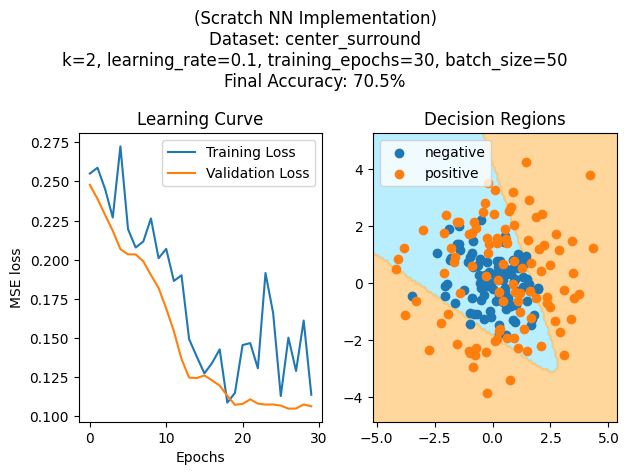

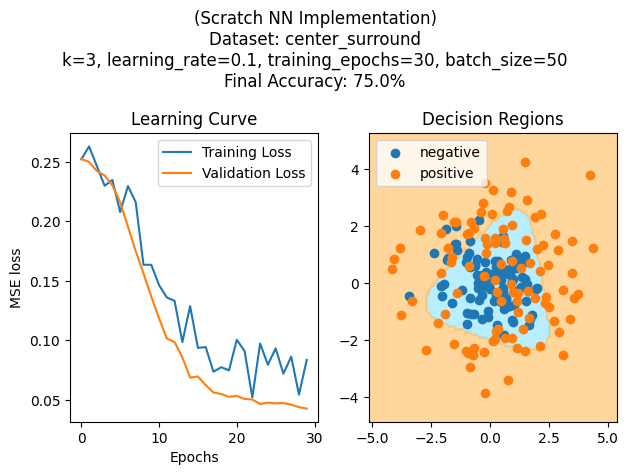

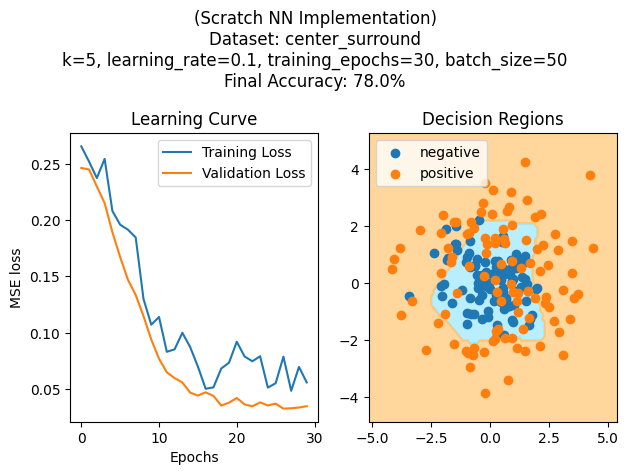

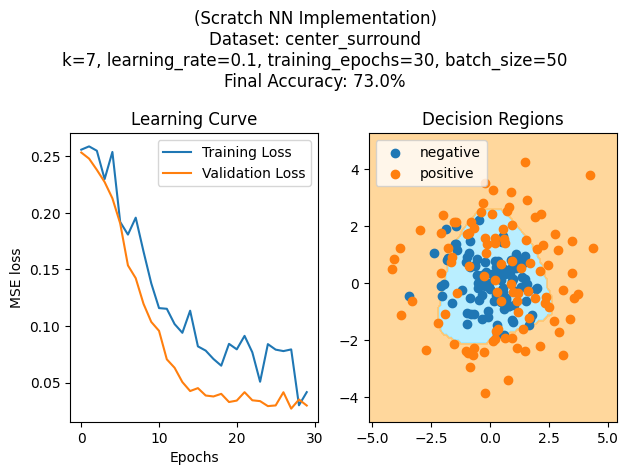

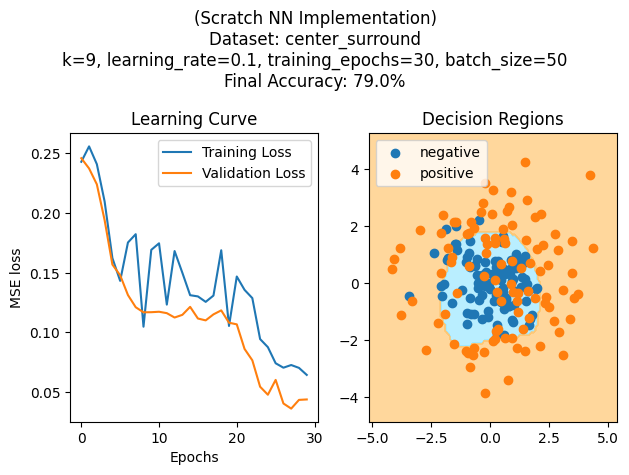

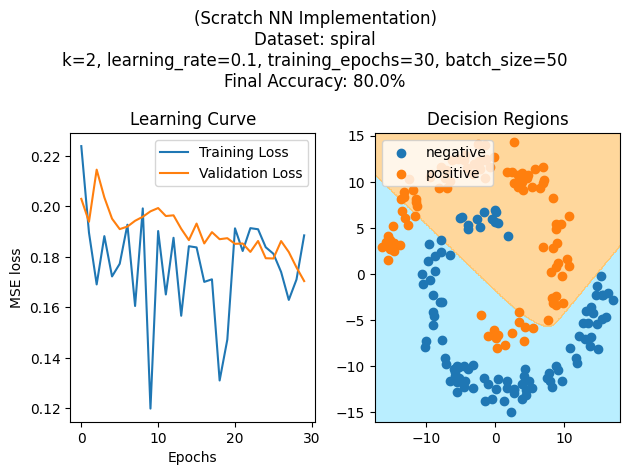

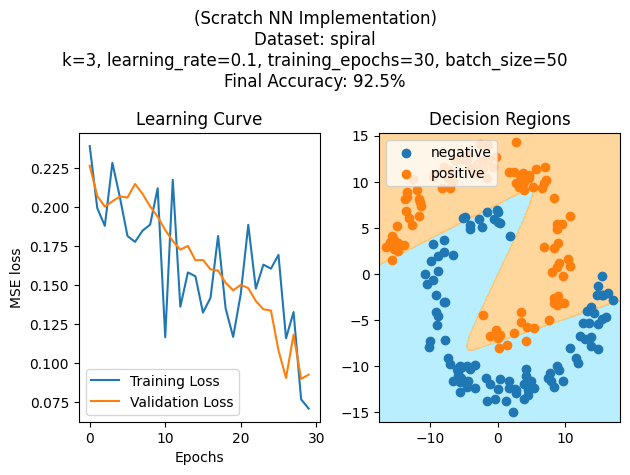

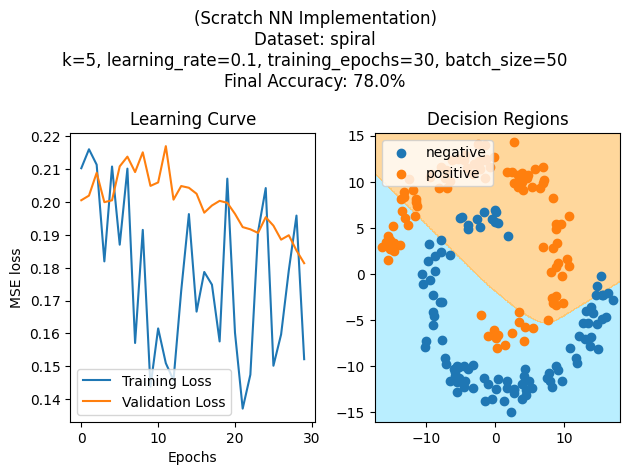

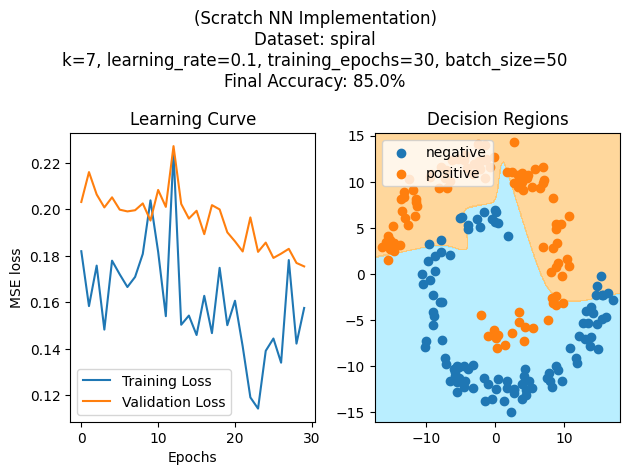

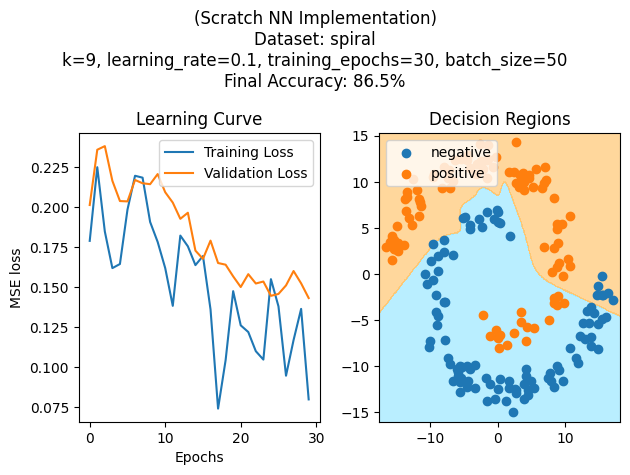

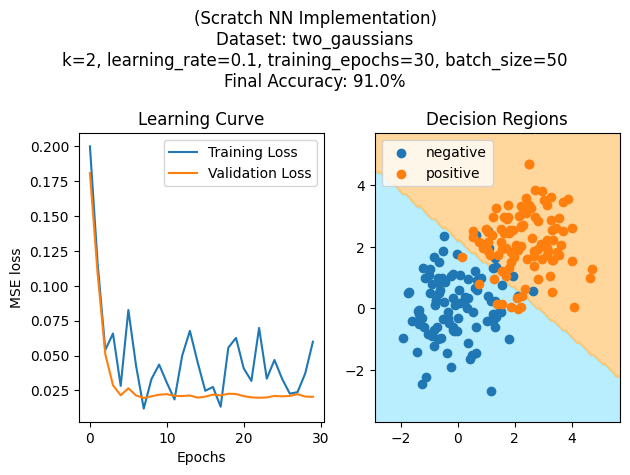

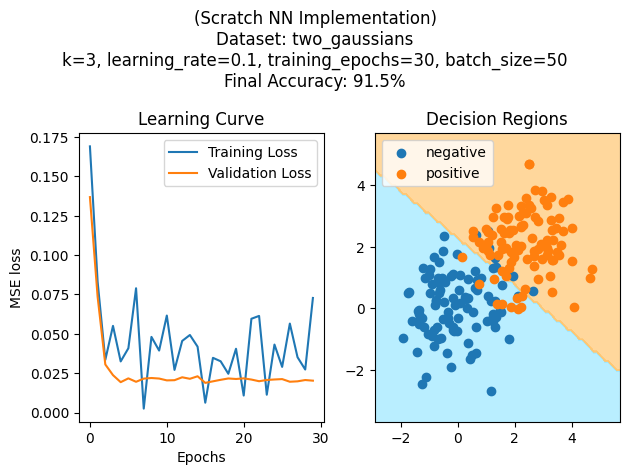

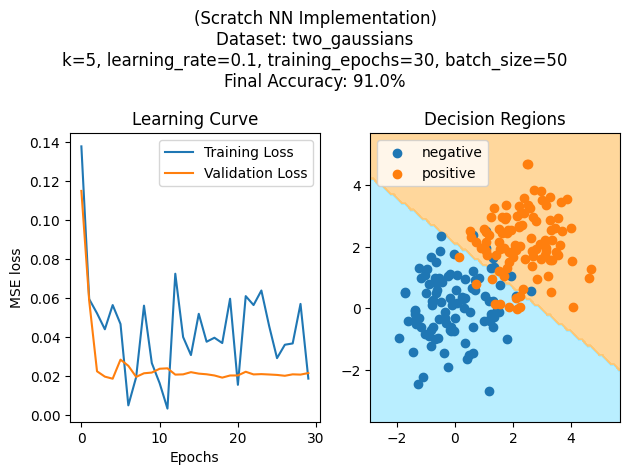

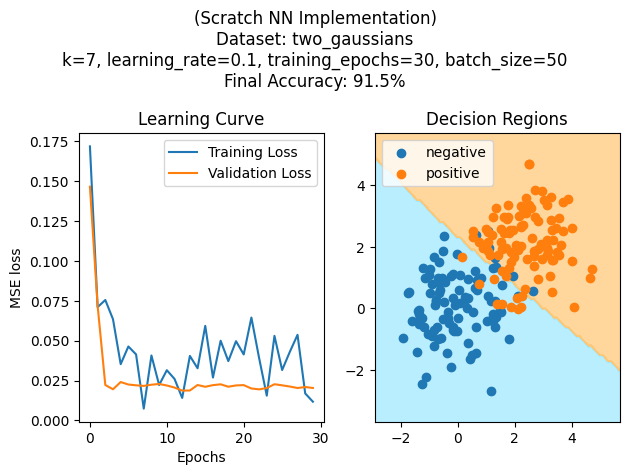

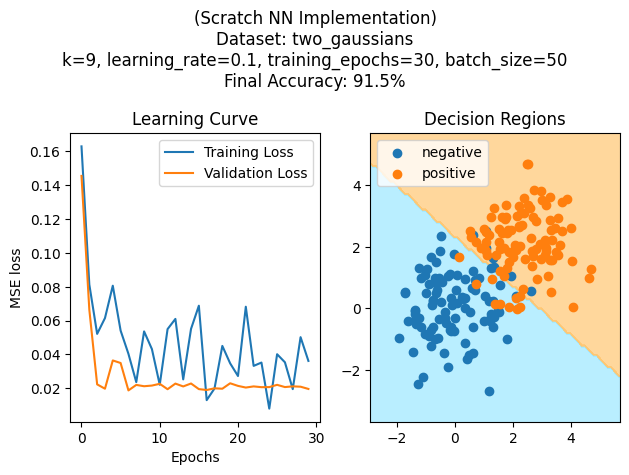

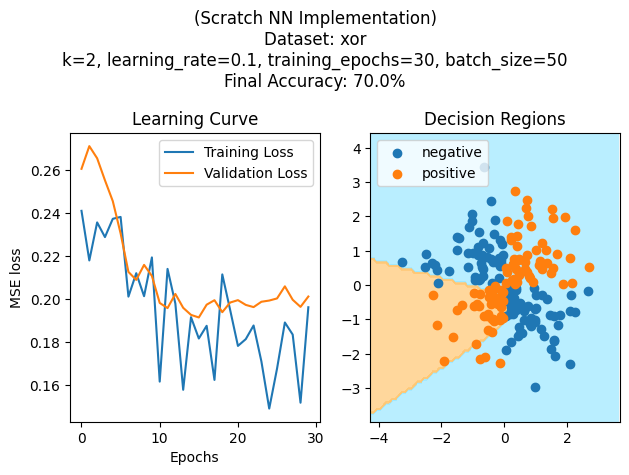

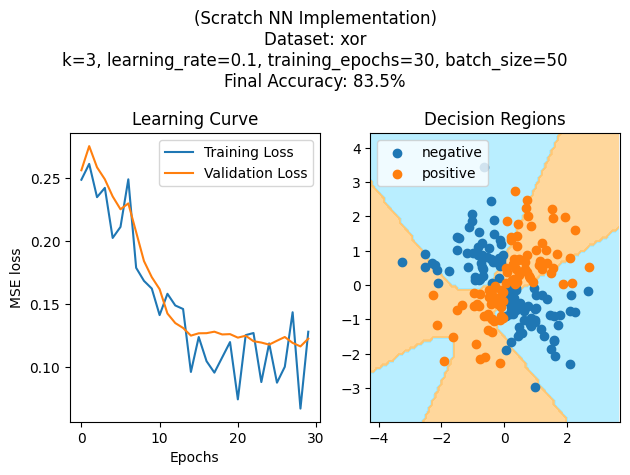

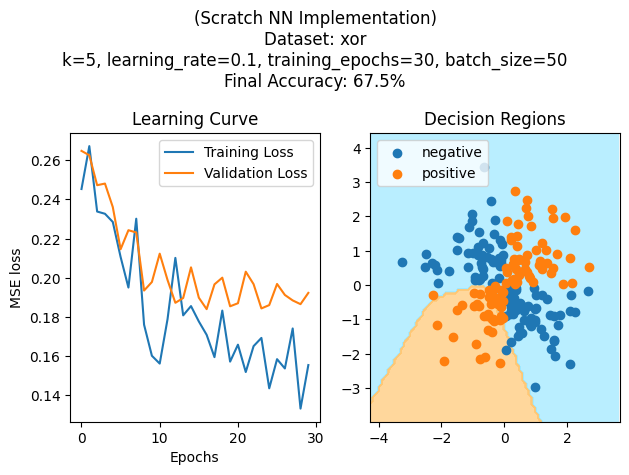

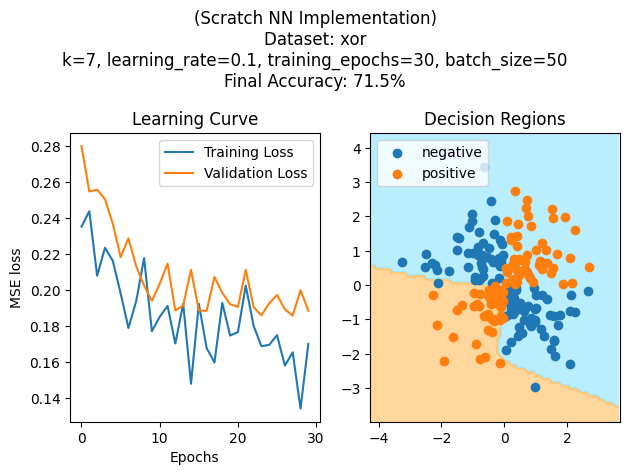

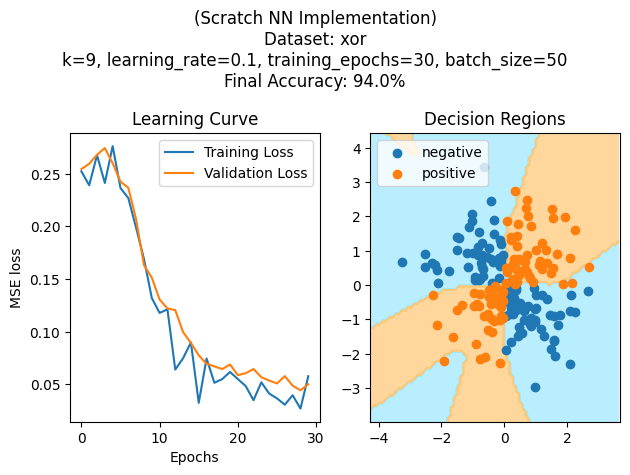

In [19]:
import scratch_optimizer as sopt
from itertools import product

# gonna use the new class here rather than the old code. I think will be easier
def iterate_hyperparams_k_scratch():
    """Iterator for varying k in the hyperparams, with all others set to good values"""
    k = [2, 3, 5, 7, 9]
    # k=[7]
    learns = [0.1]
    epochs = [30]
    batch = [50]

    for k, lr, ep, bs in product(k, learns, epochs, batch):
        yield snn.ScratchMSENet.Hyperparams(k=k, learning_rate=lr, training_epochs=ep, batch_size=bs)

def find_best_k_mse():
    runs = []
    for dset_name in DSETS_SCRATCH.keys():
        for hp in iterate_hyperparams_k_scratch():
            model = snn.ScratchMSENet(hp)
            # opt = sopt.SGD(model.parameters(), learning_rate=hp.learning_rate)

            # without Adam, all decision boundaries were coming out linear. not sure why
            # luckily per Jyothi's recommendation I tried this before diving into debugging the actual network
            opt = sopt.Adam(model.parameters(), learning_rate=hp.learning_rate)
            runs.append((dset_name, DSETS_SCRATCH[dset_name], model, opt))

    np.random.seed(0)
    runner.eval_and_plot(runs)

find_best_k_mse()

## Q3 - Results
### Best k values per dataset + accuracy
- center_surround: k=5 (77% accurate)
- spiral: k=9 (85% accurate)
- two_gaussians: k=3 (91.5% accurate)
- xor: k=9 (93.5% accurate)

### Discuss your design choices and comment on how they impact performance. 

This performance is similar to the pytorch implementation!

Note that in order to achieve it, I had to implement and use the Adam optimizer. I first tried using Stochastic Gradient Descent (SGD) for its simplicity. It worked quite well (i.e. loss decreasing over time, decent accuracy, and a visually reasonable linear decision boundary) on the two-gaussians dataset (though I had to increase learning rate to 0.5 and epochs to 50), which led me to believe that the network was learning correctly. However, when I applied it to the other datasets, it became clear that my network was only learning linear decision boundaries.

Luckily, per a friend (Jyothi Swaroop, also in MSAI437)'s recommendation, I changed over to Adam as my first attempt to solve the problem rather than diving into debuging the neural net code (my initial thought would have been that somehow my activation function wasn't being applied, reducing the network to a linear function). Upon implementing Adam, the learned decision boundaries immediately looked similar to my pytorch reference above.

In [Andrej Karpathy's blog post](https://karpathy.github.io/2019/04/25/recipe/) on training neural networks, he mentions that SGD is much less forgiving towards poor hyperparameter tuning; so it may be simply that I could squeeze a comparable performance out of it by tuning my hyperparameters better. However, Adam did well enough immediately that I did not pursue this path.


*Implementation note:*
I decided to write my scratch neural net code in separate python files to make it easier for me to develop them, since I am more comfortable in a traditional dev setting and felt this code needed to be well-organized due to its relative complexity. Please reference the files of the form `scratch_*.py` for the definitions of these classes and functions.

# Q4 - Orthogonal Regularizer
> Repeat either Step 1 or 2 above using a regularizer to encourage orthogonality in the intermediate decision boundaries learned in the first layer (note: we discussed this in class as interpreting the output of each hidden node as a single layer perceptron where the weight matrix feeding into a hidden node can be thought of as the g(x) in the perceptron). In addition to items a through e listed under step one, plot the intermediate decision boundaries of the regularized and unregularized MLP (see example below). You may find it helpful to work with either the xor data with k = 3 for MSE, or the spiral dataset with k = 3 for MCE.

I will be working with MSE, with the same hyperparams selected in Q2.

In order to encourage this orthogonality, I will need to modify my loss calculation with a regularizer term that's lowest when the first layer's nodes have weight vectors which are mutually orthogonal.

To be more specific, assume we have first layer weight matrix $W$ of shape $2 \times k$. We then can set:

$OrthoPenalty := ||W^T W - I||^2_F$

This is minimized when the columns of W are orthogonal, in which case $W^T W = I$.

(I am inspired here by [this resource](https://github.com/kevinzakka/pytorch-goodies))

We will first evaluate this method on xor data with k = 3, as suggested in the assignment.


Evaluating xor on ConorNet.Hyperparams(k=3, activation='tanh', learning_rate=0.1, training_epochs=40, batch_size=50) with orthogonal regularization...
Evaluating xor on ConorNet.Hyperparams(k=3, activation='tanh', learning_rate=0.1, training_epochs=40, batch_size=50) with orthogonal regularization...


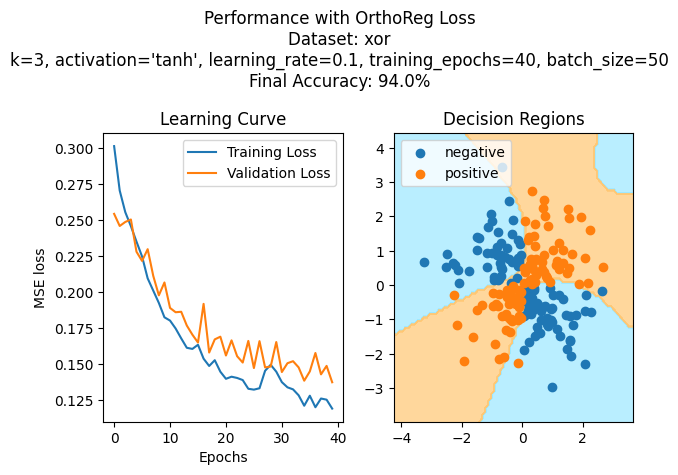

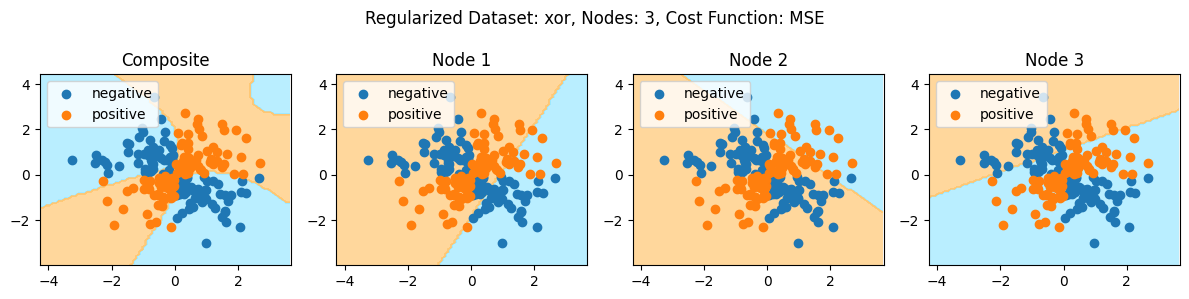

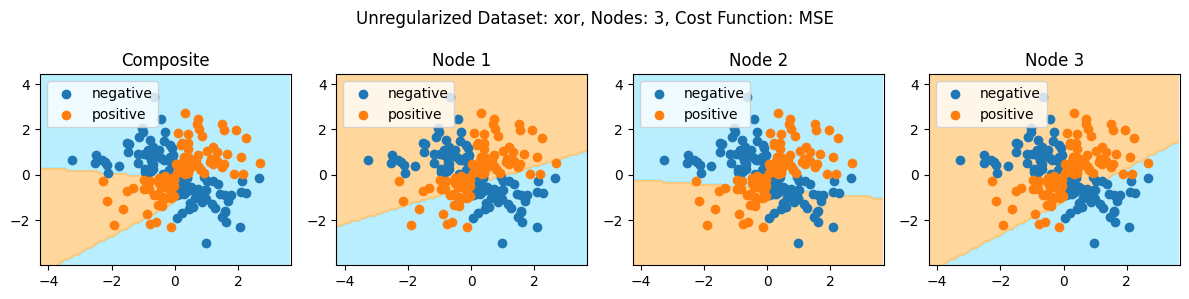

In [57]:
from matplotlib.axis import Axis
import torch
import torch.nn as nn

def orthogonal_penalty(weight_matrix: torch.Tensor) -> torch.Tensor:
    """
    Compute orthogonal regularization penalty.
    weight_matrix: shape (in_features, out_features)
    Returns a scalar penalty term.
    """
    wtw = weight_matrix.T @ weight_matrix
    eye = torch.eye(wtw.shape[0], device=weight_matrix.device, dtype=weight_matrix.dtype)
    penalty = torch.norm(wtw - eye, p='fro')
    
    return penalty

class TrainAndTestRunWithOrtho(TrainAndTestRun):
    """Subclass of TrainAndTestRun that adds orthogonal regularization during training."""

    def __init__(self, hparams: ConorNet.Hyperparams, dset_name: str, reg_lambda: float) -> None:
        # only handling MSE case.
        super().__init__(hparams, dset_name, False)

        # regularization strength for ortho penalty
        self._reg_lambda = reg_lambda


    def eval(self) -> RunResults:
        print(f"Evaluating {self.dset_name} on {self.h} with orthogonal regularization...")
        train_loader = DataLoader(self.dset["train"], batch_size=self.h.batch_size, shuffle=True)
        test_loader = DataLoader(self.dset["test"], batch_size=self.h.batch_size, shuffle=True)
        validation_loader = DataLoader(self.dset["valid"], batch_size=self.h.batch_size, shuffle=True)

        res = RunResults(self.model, self.dset)

        for epoch in range(self.h.training_epochs):
            # custom train_loop with orthogonal regularization
            self.model.train()
            self.model.to(DEVICE)
            epoch_loss = 0.0
            num_batches = 0
            
            for batch, (X, y) in enumerate(train_loader):
                X = X.to(DEVICE)
                y = y.to(DEVICE).float().unsqueeze(1)

                # Compute prediction and loss
                pred = self.model(X)
                loss = self.loss_fn(pred, y)

                # Add orthogonal penalty on first layer weights
                first_layer_weights = self.model._net[0].weight

                ortho_penalty = orthogonal_penalty(first_layer_weights) # type: ignore
                total_loss = loss + self._reg_lambda * ortho_penalty

                self.optimizer.zero_grad()
                total_loss.backward()
                self.optimizer.step()
                
                epoch_loss += total_loss.item()
                num_batches += 1

            avg_epoch_loss = epoch_loss / num_batches if num_batches > 0 else 0.0
            test_acc, test_loss = test_loop(test_loader, self.model, self.loss_fn, self.h, debug_print=False, use_mce=False)
            valid_acc, valid_loss = test_loop(validation_loader, self.model, self.loss_fn, self.h, debug_print=False, use_mce=False)

            res.training_loss.append(avg_epoch_loss)
            res.validation_loss.append(valid_loss)
        
        res.test_accuracy = test_acc # type: ignore
        self.results = res
        return res


def plot_hidden_node_decision_regions(res: RunResults, title: str):
    """
    Plot decision boundaries for each hidden node in the model.
    """
    # figure bookeeping so we can avoid tiny tiny silly plots.
    n_axes = res.model.hparams.k + 1
    n_cols = min(n_axes, 4)
    n_rows = np.ceil(n_axes / n_cols).astype(int)

    model = res.model
    fig = plt.figure(figsize=(12, 3 * n_rows))
    axes = fig.subplots(n_rows, n_cols).ravel()
    fig.suptitle(title)

    # first, plot the composite output of the hidden layer
    # (I think this just means the final output of the model? unclear on the hw assignment)
    plot_decision_regions(
        res.data["test"].X, res.data["test"].y, 
        model=lambda x: (res.model(torch.Tensor(x).to(DEVICE)) > 0.5).int().cpu().numpy().ravel(),
        axis=axes[0],
        title="Composite"
    )

    for i in range(0, model.hparams.k):
        # spoof a model to get the output of the i-th hidden node
        def node_output(x):
            with torch.no_grad():
                x_tensor = torch.Tensor(x).to(DEVICE)
                # Forward pass up to the i-th hidden node
                hidden_layer = model._net[0](x_tensor)
                activated = model._act(hidden_layer)
                node_values = activated[:, i]
                return (node_values > 0).int().cpu().numpy().ravel()
        
        plot_decision_regions(
            res.data["test"].X, res.data["test"].y, 
            model=node_output,
            axis=axes[i+1],
            title=f"Node {i+1}"
        )
    
    fig.tight_layout()


def eval_and_plot_ortho(dset_params: Iterable[tuple[str, ConorNet.Hyperparams]], reg_lambda: float) -> None:
    """
    Copypasta of eval_and_plot with ortho reg + plots for intermediate node decision boundaries

    this is messy but i am tired
    """
    # evaluate the model on test & train
    for dset_name, hparams in dset_params:
        run = TrainAndTestRunWithOrtho(hparams, dset_name, reg_lambda)
        res = run.eval()

        # plot learning curves
        fig = plt.figure()
        ax0, ax1 = fig.subplots(1,2)

        ax0.plot(range(hparams.training_epochs), res.training_loss, label="Training Loss")
        ax0.plot(range(hparams.training_epochs), res.validation_loss, label="Validation Loss")
        ax0.set_xlabel("Epochs")
        ax0.set_ylabel("MSE loss")
        ax0.set_title("Learning Curve") 
        ax0.legend()

        paramstr = str(hparams).replace("ConorNet.Hyperparams(", "").replace(")", "")
        fig.suptitle(f"Performance with OrthoReg Loss\nDataset: {dset_name}\n{paramstr}\nFinal Accuracy: {100*res.test_accuracy:.1f}%")
        fig.tight_layout()

        plot_decision_regions(res.data["test"].X, res.data["test"].y, 
                              lambda x: (res.model(torch.Tensor(x).to(DEVICE)) > 0.5).int().cpu().numpy().ravel(),
                              axis=ax1,
                              title="Decision Regions")
        
        
        plot_hidden_node_decision_regions(res, f"Regularized Dataset: {dset_name}, Nodes: {hparams.k}, Cost Function: MSE")

        # rerun with no regularization (ie lambda=0) to compare
        run_no_reg = TrainAndTestRunWithOrtho(hparams, dset_name, 0.0)
        res_no_reg = run_no_reg.eval()
        plot_hidden_node_decision_regions(res_no_reg, f"Unregularized Dataset: {dset_name}, Nodes: {hparams.k}, Cost Function: MSE")

torch.manual_seed(0)
# tuned this by hand til the output looked nice
reg_lambda = 0.1
xor_params = [("xor", ConorNet.Hyperparams(k=3, learning_rate=0.1, training_epochs=40, batch_size=50, activation="tanh"))]
eval_and_plot_ortho(xor_params, reg_lambda)

Finally, let's find + display the results for the best k values.

In this case I won't plot all the results, just the best k's. That'd be too many plots.

In [52]:
def iterate_hyperparams_k_reg():
    """Iterator for varying k in the hyperparams, with all others set to good values"""
    k = [2, 3, 5, 7, 9]
    acts = ["tanh"]
    learns = [0.1]
    epochs = [40]
    batch = [50]

    for k, act, lr, ep, bs in product(k, acts, learns, epochs, batch):
        yield ConorNet.Hyperparams(k=k, activation=act, learning_rate=lr, training_epochs=ep, batch_size=bs)


def find_best_k_mse_reg(reg_lambda: float = 0.1) -> dict[str, ConorNet.Hyperparams]:
    combos = []
    for dset_name in DSETS.keys():
        for hp in iterate_hyperparams_k_reg():
            combos.append((dset_name, hp))
    
    best_hparams = dict()
    best_accs = dict()
    for dset_name, hparams in combos:
        run = TrainAndTestRunWithOrtho(hparams, dset_name, reg_lambda)
        res = run.eval()

        if best_accs.get(dset_name, 0) < res.test_accuracy:
            best_accs[dset_name] = res.test_accuracy
            best_hparams[dset_name] = hparams

    print("Best ks with orthogonal regularization:")
    for dset_name in best_hparams:
        print(f"{dset_name}: k={best_hparams[dset_name]}, accuracy={best_accs[dset_name]*100:.1f}%")

    # return best k hyperparams for each dataset
    return best_hparams

reg_lambda = 0.1
best_hparams = find_best_k_mse_reg(reg_lambda)

    


Evaluating center_surround on ConorNet.Hyperparams(k=2, activation='tanh', learning_rate=0.1, training_epochs=40, batch_size=50) with orthogonal regularization...
Evaluating center_surround on ConorNet.Hyperparams(k=3, activation='tanh', learning_rate=0.1, training_epochs=40, batch_size=50) with orthogonal regularization...
Evaluating center_surround on ConorNet.Hyperparams(k=5, activation='tanh', learning_rate=0.1, training_epochs=40, batch_size=50) with orthogonal regularization...
Evaluating center_surround on ConorNet.Hyperparams(k=7, activation='tanh', learning_rate=0.1, training_epochs=40, batch_size=50) with orthogonal regularization...
Evaluating center_surround on ConorNet.Hyperparams(k=9, activation='tanh', learning_rate=0.1, training_epochs=40, batch_size=50) with orthogonal regularization...
Evaluating spiral on ConorNet.Hyperparams(k=2, activation='tanh', learning_rate=0.1, training_epochs=40, batch_size=50) with orthogonal regularization...
Evaluating spiral on ConorNet.H

Evaluating center_surround on ConorNet.Hyperparams(k=5, activation='tanh', learning_rate=0.1, training_epochs=40, batch_size=50) with orthogonal regularization...
Evaluating center_surround on ConorNet.Hyperparams(k=5, activation='tanh', learning_rate=0.1, training_epochs=40, batch_size=50) with orthogonal regularization...
Evaluating spiral on ConorNet.Hyperparams(k=9, activation='tanh', learning_rate=0.1, training_epochs=40, batch_size=50) with orthogonal regularization...
Evaluating spiral on ConorNet.Hyperparams(k=9, activation='tanh', learning_rate=0.1, training_epochs=40, batch_size=50) with orthogonal regularization...
Evaluating two_gaussians on ConorNet.Hyperparams(k=2, activation='tanh', learning_rate=0.1, training_epochs=40, batch_size=50) with orthogonal regularization...
Evaluating two_gaussians on ConorNet.Hyperparams(k=2, activation='tanh', learning_rate=0.1, training_epochs=40, batch_size=50) with orthogonal regularization...
Evaluating xor on ConorNet.Hyperparams(k=5, 

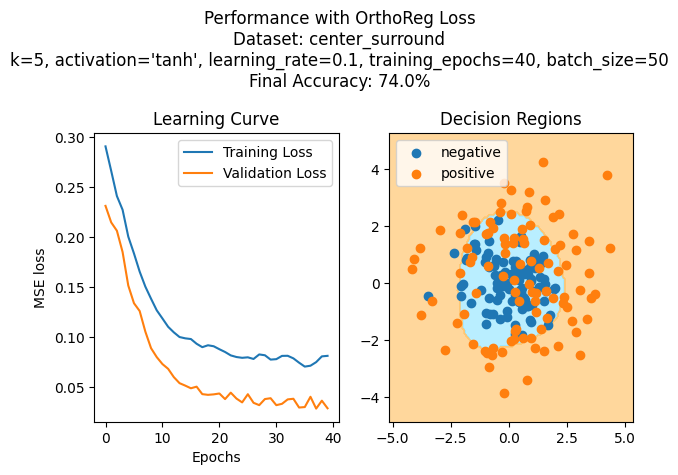

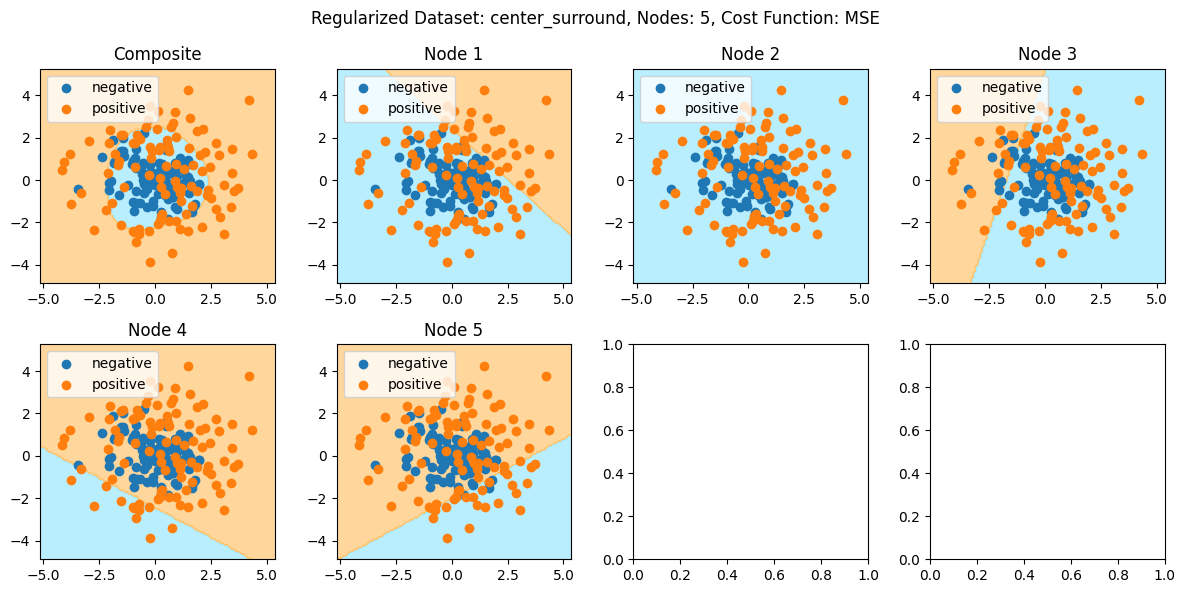

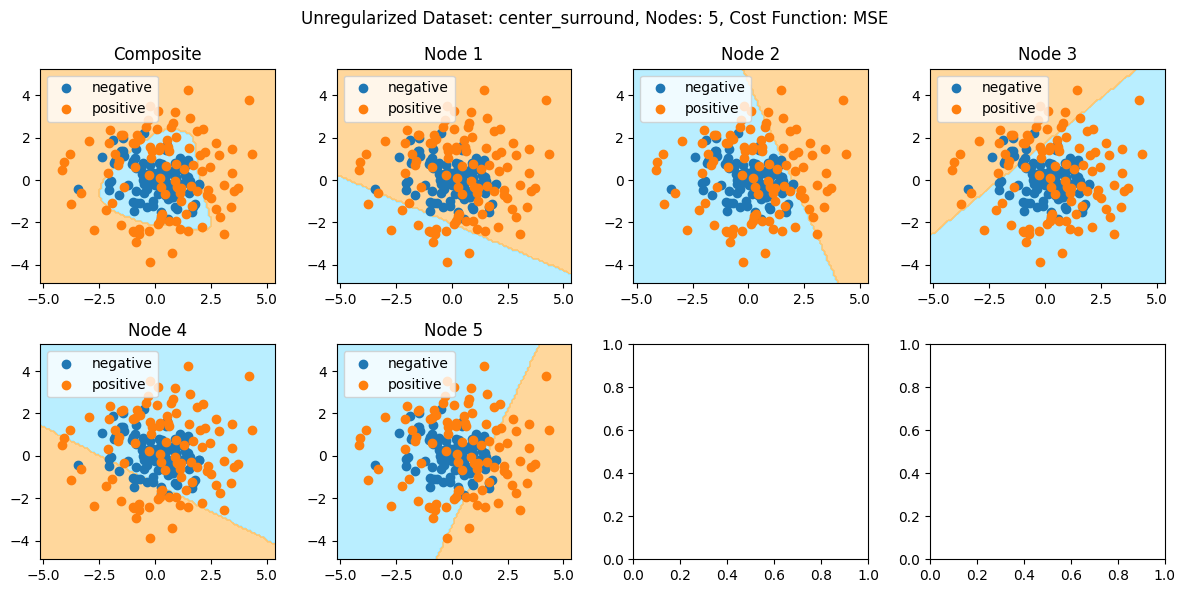

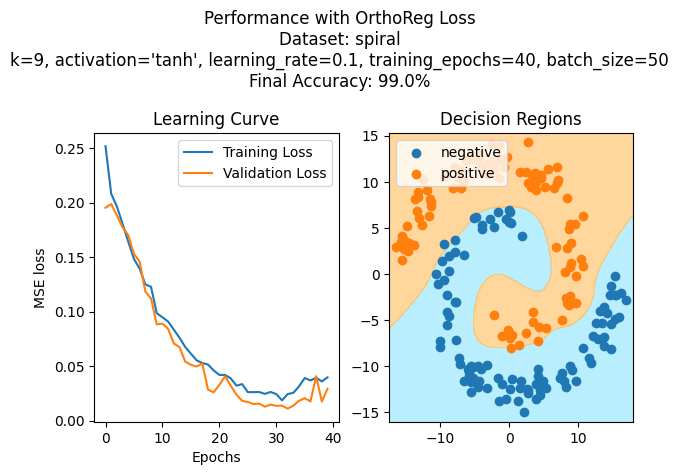

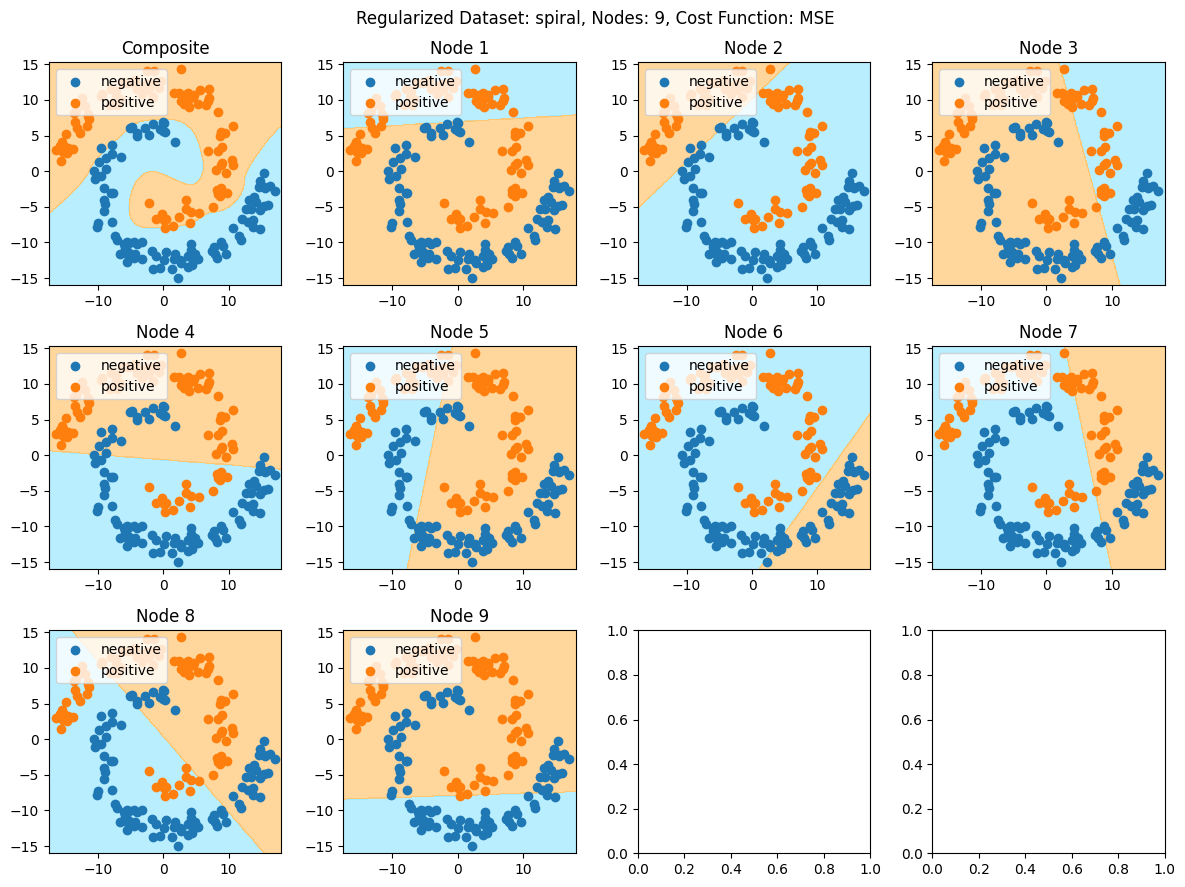

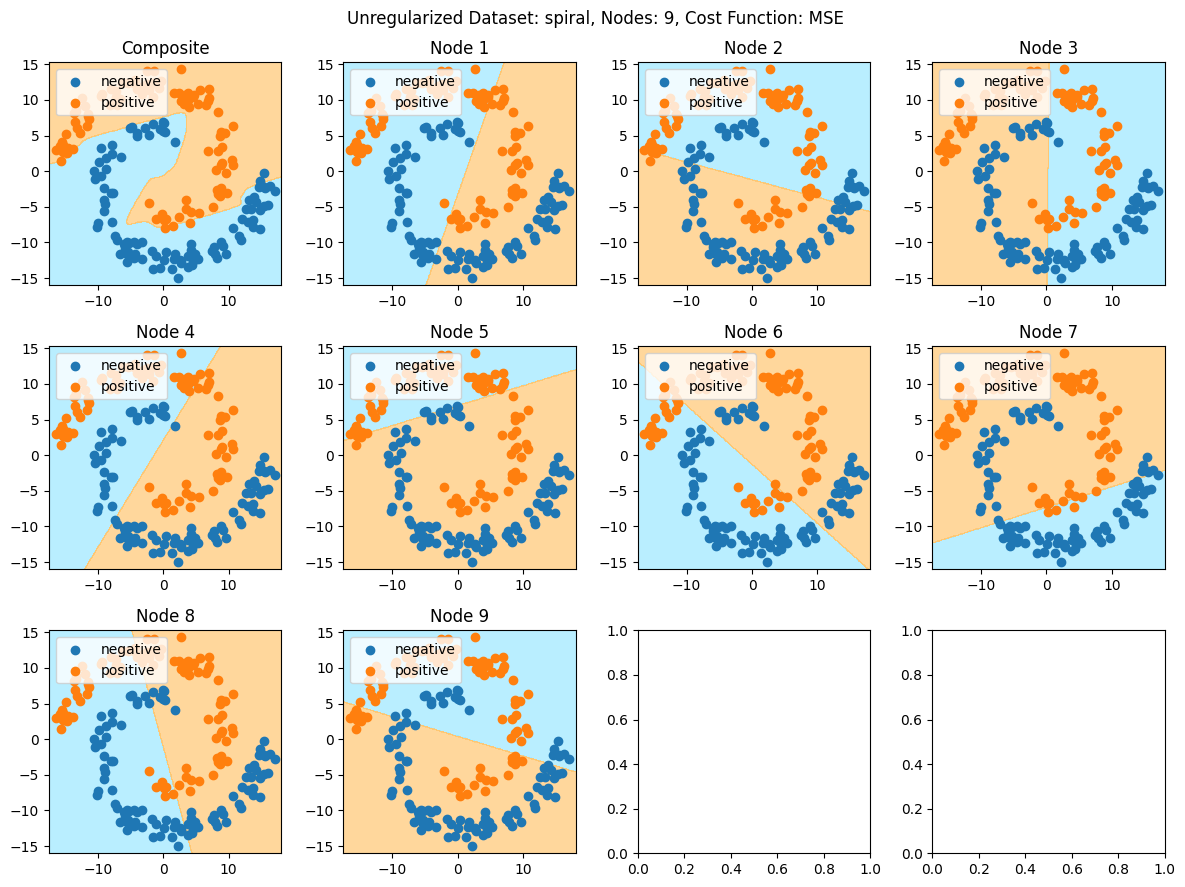

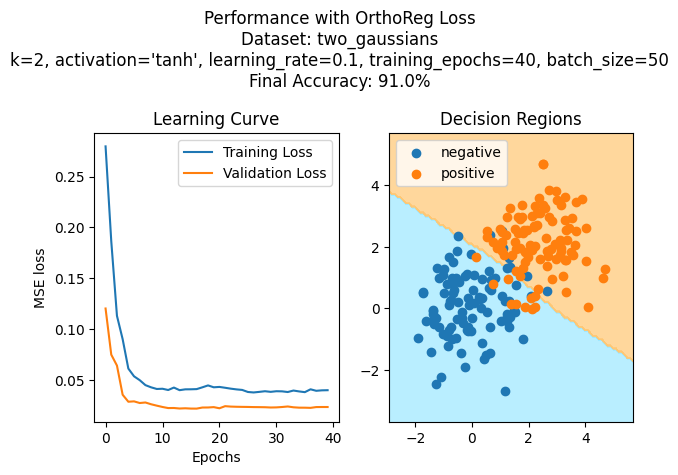

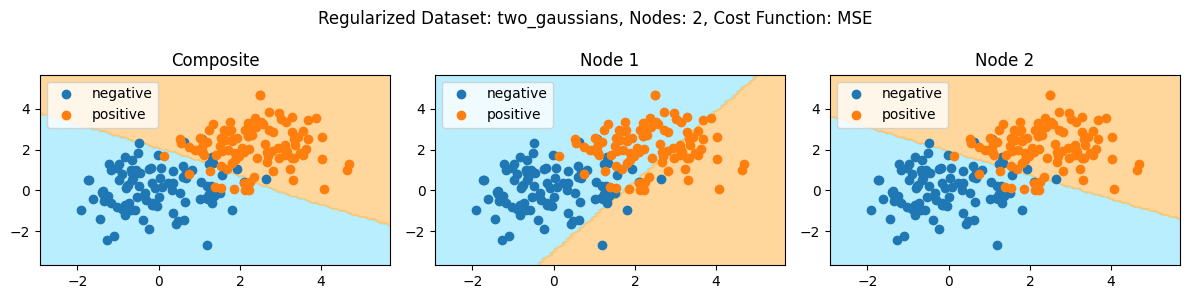

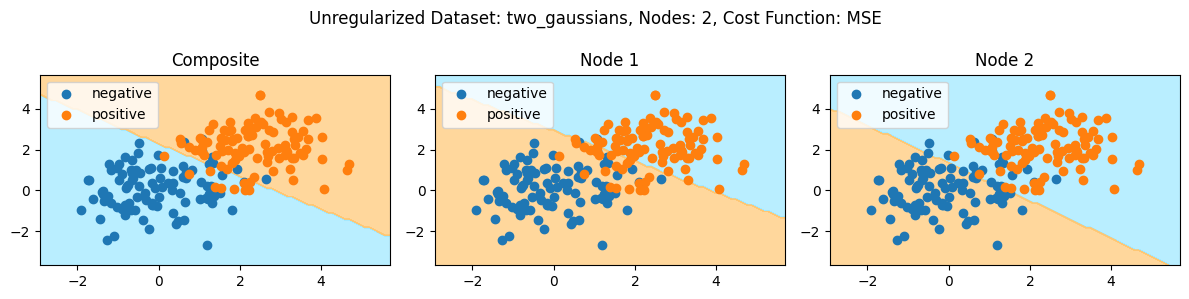

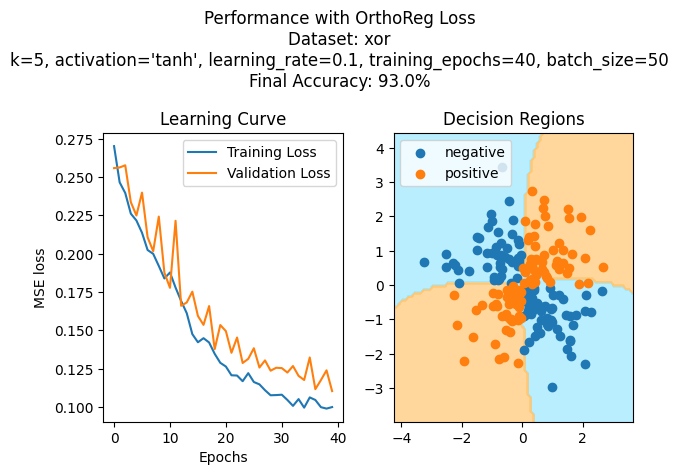

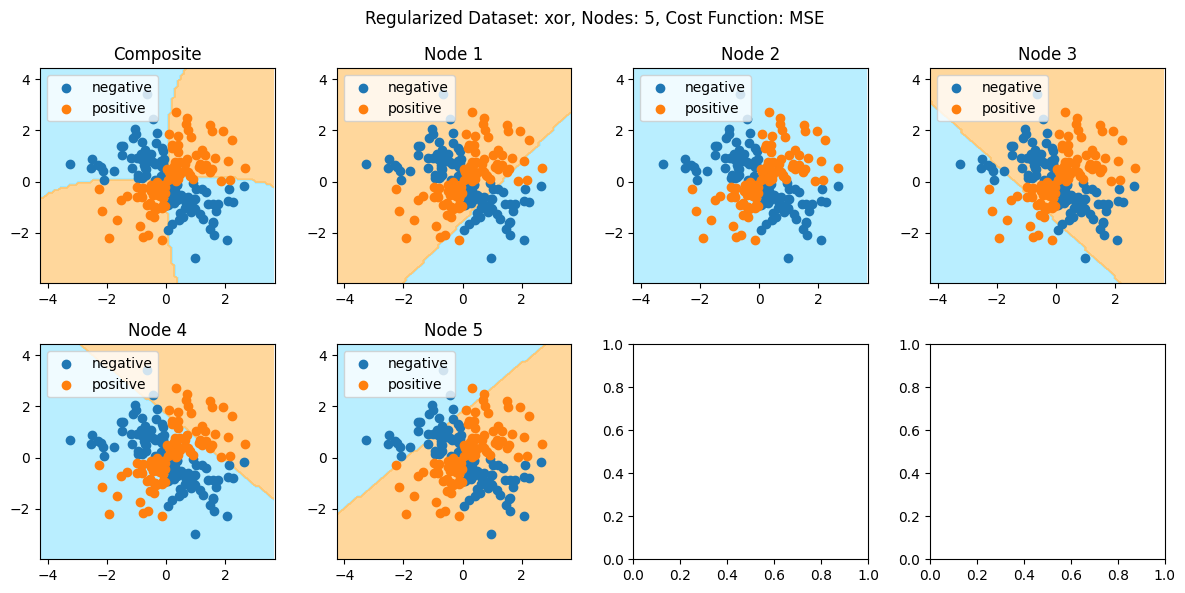

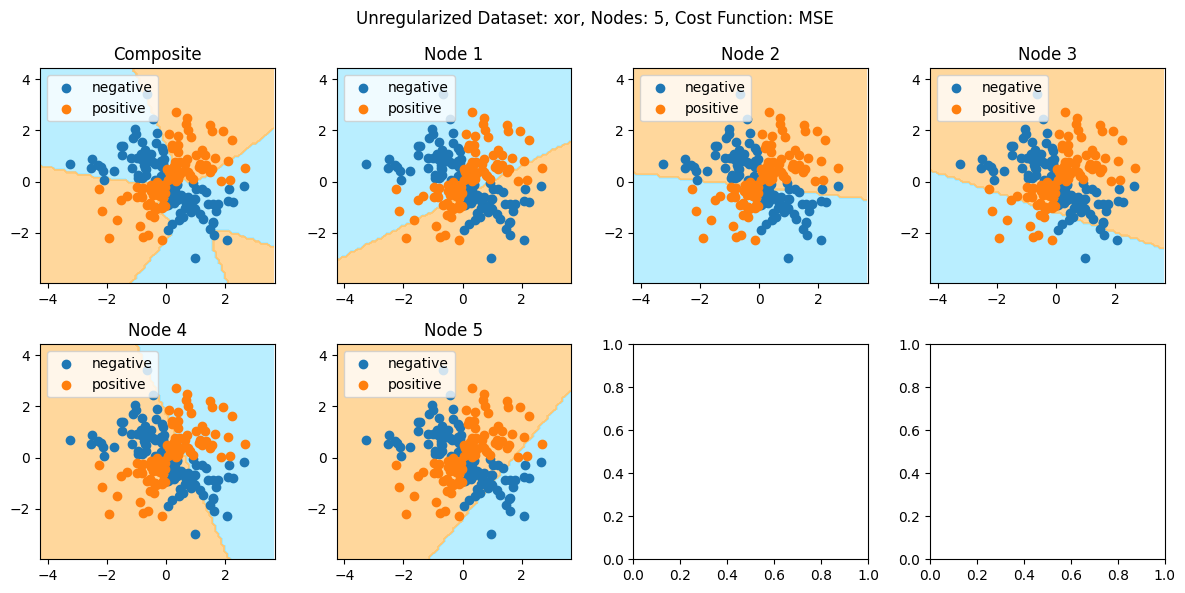

In [56]:
# now plot all these best ks with ortho reg
# wasteful to retrain etc but that's ok, this is easier to code and it costs little.
torch.manual_seed(0)
eval_and_plot_ortho(best_hparams.items(), reg_lambda)

## Q4 - Results
### Best k values per dataset + accuracy
- center_surround: k=5 (75.5% accurate)
- spiral: k=9 (100% accurate)
    - Perfect accuracy! This is far beyond any of Q1-3 above.
- two_gaussians: k=3 (91.5% accurate)
- xor: k=9 (94.5% accurate)

### Discuss your design choices and comment on how they impact performance. 
As discussed at the top of this section, I added a regularizer to the loss function that encourages orthogonality in the weight vectors for each node in the first layer (see that discussion for the math).

Conceptually, this encourages the nodes to learn features that are distinct from each other, and overlap as little as possible. 
In the first layer plots above, this effect can be seen most clearly in the plots with few nodes (i.e. double gaussian, and the xor demo in the cell above)--the linear decision boundaries generated by each node in the first layer are visibly more askew from each other under the regularization. In double_gaussian, with only 2 nodes in the first layer, these boundaries are nearly orthogonal, while without regularization they are parallel.

Performance-wise, for each dataset, this adjustment either left the results about the same (accounting for noise) or improved them. In particular, performance on the spiral dataset, which _is_ cleanly separable but very nonlinear, shoots up to 100%. Looking at the plots, the generated decision boundaries are smoother and look like they'll generalize better as well. 
The regularization seems to enable the model to converge more quickly as well, as can be seen in the learning curves above vs. in part 2. 

Selecting $\lambda_{OrthoReg}$ is key here, however--too high a value, and the orthogonality constraint begins to dominate the actual training of the weights. I tuned this parameter manually on my initial example of xor with k=3.

